# Supervised Learning - Foundations Project: ReCell

## Problem Statement

### Business Context

Buying and selling used phones and tablets used to be something that happened on a handful of online marketplace sites. But the used and refurbished device market has grown considerably over the past decade, and a new IDC (International Data Corporation) forecast predicts that the used phone market would be worth \\$52.7bn by 2023 with a compound annual growth rate (CAGR) of 13.6% from 2018 to 2023. This growth can be attributed to an uptick in demand for used phones and tablets that offer considerable savings compared with new models.

Refurbished and used devices continue to provide cost-effective alternatives to both consumers and businesses that are looking to save money when purchasing one. There are plenty of other benefits associated with the used device market. Used and refurbished devices can be sold with warranties and can also be insured with proof of purchase. Third-party vendors/platforms, such as Verizon, Amazon, etc., provide attractive offers to customers for refurbished devices. Maximizing the longevity of devices through second-hand trade also reduces their environmental impact and helps in recycling and reducing waste. The impact of the COVID-19 outbreak may further boost this segment as consumers cut back on discretionary spending and buy phones and tablets only for immediate needs.


### Objective

The rising potential of this comparatively under-the-radar market fuels the need for an ML-based solution to develop a dynamic pricing strategy for used and refurbished devices. ReCell, a startup aiming to tap the potential in this market, has hired you as a data scientist. They want you to analyze the data provided and build a linear regression model to predict the price of a used phone/tablet and identify factors that significantly influence it.


### Data Description

The data contains the different attributes of used/refurbished phones and tablets. The data was collected in the year 2021. The detailed data dictionary is given below.


- brand_name: Name of manufacturing brand
- os: OS on which the device runs
- screen_size: Size of the screen in cm
- 4g: Whether 4G is available or not
- 5g: Whether 5G is available or not
- main_camera_mp: Resolution of the rear camera in megapixels
- selfie_camera_mp: Resolution of the front camera in megapixels
- int_memory: Amount of internal memory (ROM) in GB
- ram: Amount of RAM in GB
- battery: Energy capacity of the device battery in mAh
- weight: Weight of the device in grams
- release_year: Year when the device model was released
- days_used: Number of days the used/refurbished device has been used
- normalized_new_price: Normalized price of a new device of the same model in euros
- normalized_used_price: Normalized price of the used/refurbished device in euros

## Importing necessary libraries

In [ ]:
# Installing the libraries with the specified version.
# uncomment and run the following line if Google Colab is being used
!pip install scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.3 -q --user

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.8/294.8 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 23.6 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 24.10.1 requires pandas<2.2.3dev0,>=2.0, but you have pandas 1.5.3 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 1.5.3 which is incompatible.
imbalanced-learn 0.13.0 requires scikit-learn<2,>=1.3.2, but you have scikit-learn 1.2.2 which is incompatible.
mizani 0.1

In [ ]:
#Import libraries
import pandas as pd
import numpy as np

# for visualizing data
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# For randomized data splitting
from sklearn.model_selection import train_test_split

# To build linear regression_model
import statsmodels.api as sm

# To check model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



## Loading the dataset

In [ ]:
# Mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/used_device_data.csv')

## Data Overview

###Displaying the first few rows of the dataset

In [ ]:
data.head()

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
0,Honor,Android,14.50,yes,no,13.0,5.0,64.0,3.0,3020.0,146.0,2020,127,4.307572,4.715100
1,Honor,Android,17.30,yes,yes,13.0,16.0,128.0,8.0,4300.0,213.0,2020,325,5.162097,5.519018
2,Honor,Android,16.69,yes,yes,13.0,8.0,128.0,8.0,4200.0,213.0,2020,162,5.111084,5.884631
3,Honor,Android,25.50,yes,yes,13.0,8.0,64.0,6.0,7250.0,480.0,2020,345,5.135387,5.630961
4,Honor,Android,15.32,yes,no,13.0,8.0,64.0,3.0,5000.0,185.0,2020,293,4.389995,4.947837


In [ ]:
data.tail()


,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
3449,Asus,Android,15.34,yes,no,NaN,8.0,64.0,6.0,5000.0,190.0,2019,232,4.492337,6.483872
3450,Asus,Android,15.24,yes,no,13.0,8.0,128.0,8.0,4000.0,200.0,2018,541,5.037732,6.251538
3451,Alcatel,Android,15.80,yes,no,13.0,5.0,32.0,3.0,4000.0,165.0,2020,201,4.357350,4.528829
3452,Alcatel,Android,15.80,yes,no,13.0,5.0,32.0,2.0,4000.0,160.0,2020,149,4.349762,4.624188
3453,Alcatel,Android,12.83,yes,no,13.0,5.0,16.0,2.0,4000.0,168.0,2020,176,4.132122,4.279994


In [ ]:
data.shape

(3454, 15)

- There are 3454 rows and 15 columns in the dataset.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3454 entries, 0 to 3453
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand_name             3454 non-null   object 
 1   os                     3454 non-null   object 
 2   screen_size            3454 non-null   float64
 3   4g                     3454 non-null   object 
 4   5g                     3454 non-null   object 
 5   main_camera_mp         3275 non-null   float64
 6   selfie_camera_mp       3452 non-null   float64
 7   int_memory             3450 non-null   float64
 8   ram                    3450 non-null   float64
 9   battery                3448 non-null   float64
 10  weight                 3447 non-null   float64
 11  release_year           3454 non-null   int64  
 12  days_used              3454 non-null   int64  
 13  normalized_used_price  3454 non-null   float64
 14  normalized_new_price   3454 non-null   float64
dtypes: f

- Datatypes consists of: 9 float columns, 2 integer and 4 object.
- There appears to be
 in the main and selfie camera columns as well as int_memory, ram, battery and weight columns
- The target variable is normalized_used_price which is a float type


### Statistical summary of the dataset


In [ ]:
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
brand_name,3454,34,Others,502,NaN,NaN,NaN,NaN,NaN,NaN,NaN
os,3454,4,Android,3214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
screen_size,3454.0,NaN,NaN,NaN,13.713115,3.80528,5.08,12.7,12.83,15.34,30.71
4g,3454,2,yes,2335,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5g,3454,2,no,3302,NaN,NaN,NaN,NaN,NaN,NaN,NaN
main_camera_mp,3275.0,NaN,NaN,NaN,9.460208,4.815461,0.08,5.0,8.0,13.0,48.0
selfie_camera_mp,3452.0,NaN,NaN,NaN,6.554229,6.970372,0.0,2.0,5.0,8.0,32.0
int_memory,3450.0,NaN,NaN,NaN,54.573099,84.972371,0.01,16.0,32.0,64.0,1024.0
ram,3450.0,NaN,NaN,NaN,4.036122,1.365105,0.02,4.0,4.0,4.0,12.0
battery,3448.0,NaN,NaN,NaN,3133.402697,1299.682844,500.0,2100.0,3000.0,4000.0,9720.0


- Android is the top seller operating system with an count of 3214
- Screensize varies between 5.0 and 30.71 cm with a mean size of 13.71 cm.
- 5G is most frequent.
- The main camera average megapixels are 9.56 mp, and the selfie camera average megapixels are 6.55 mp.
- The average internal memory is 54.4 GB, with a range between 0.01 and 64 GB. The average RAM is 4 GB.
- The average days used are 675.
- The average device weight is 182.75 gram.
- The phones were released between 2013 and 2020, with the average of phones being released in 2015. It will be of value to know the exact age of the phones.
- The average price of a new phone is 5.4 Euro.
-The average price of a used phone is 4.3 Euro.

### Checking for duplicate values

In [ ]:
data.duplicated().sum()

0

- There a no duplicate values

### Checking for missing values

In [ ]:
data.isnull().sum()

,0
brand_name,0
os,0
screen_size,0
4g,0
5g,0
main_camera_mp,179
selfie_camera_mp,2
int_memory,4
ram,4
battery,6


- There are missing values.
- The main camera megapixels has the most missing values of 179.
- The other missing values are only a few numbers.

In [ ]:
# creating a copy of the data so that original data remains unchanged
df = data.copy()

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What does the distribution of normalized used device prices look like?
2. What percentage of the used device market is dominated by Android devices?
3. The amount of RAM is important for the smooth functioning of a device. How does the amount of RAM vary with the brand?
4. A large battery often increases a device's weight, making it feel uncomfortable in the hands. How does the weight vary for phones and tablets offering large batteries (more than 4500 mAh)?
5. Bigger screens are desirable for entertainment purposes as they offer a better viewing experience. How many phones and tablets are available across different brands with a screen size larger than 6 inches?
6. A lot of devices nowadays offer great selfie cameras, allowing us to capture our favorite moments with loved ones. What is the distribution of devices offering greater than 8MP selfie cameras across brands?
7. Which attributes are highly correlated with the normalized price of a used device?

### Distribution of normalized used device prices

In [ ]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram


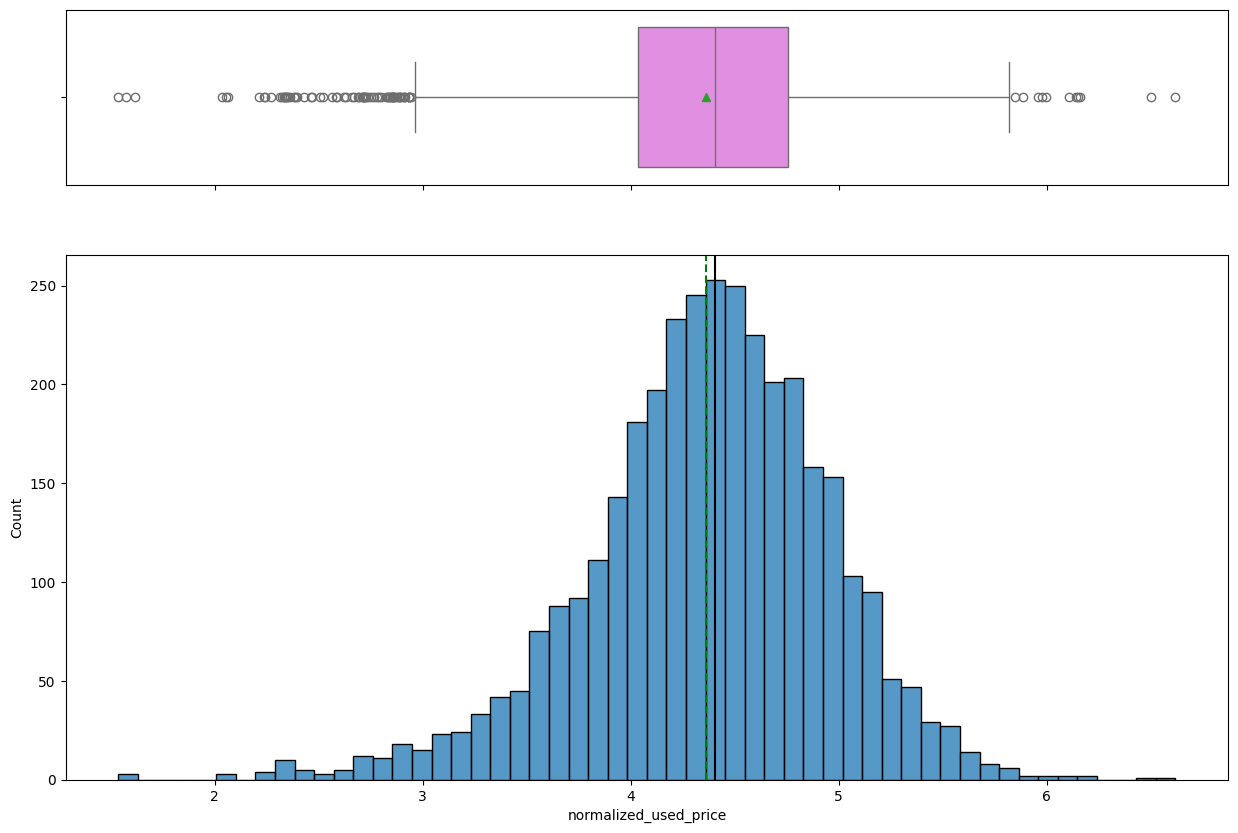

In [ ]:
# Histogram_boxplot of normalized used prices
histogram_boxplot(df, 'normalized_used_price')

- The distribution of the normalized used price are slightly shewed to the left.
- The average price is approximately 4.4 Euros.

### Percentage of the used device market is dominated by Android devices

In [ ]:
#function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

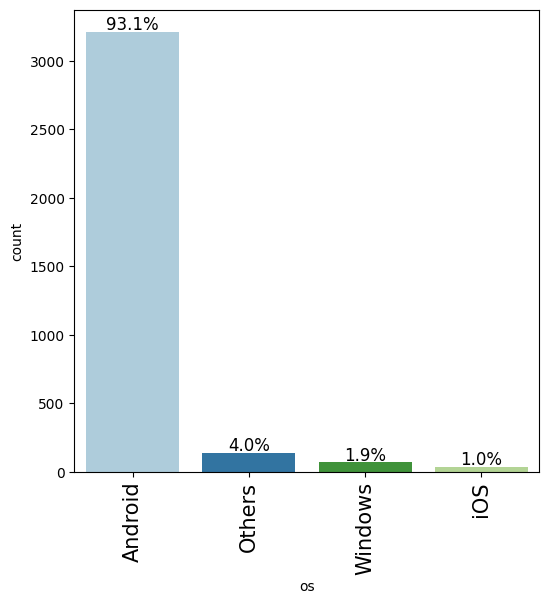

In [ ]:
labeled_barplot(df,"os", perc=True)

- 93.1% are Android operated phones.
- 1.9% are Windows operated phones.
- 1.0% are iOS operated phones.
- 4.0% are operated by other systems.


### Distribution of RAM varied by brand

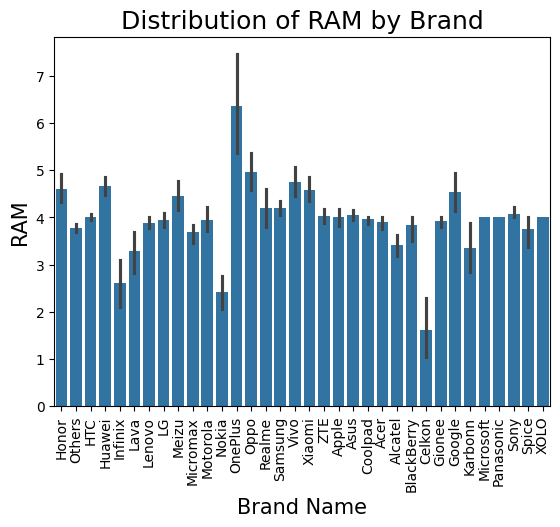

In [ ]:
sns.barplot(df,x='brand_name',y='ram')
plt.xticks(rotation=90)
#label x axis
plt.xlabel('Brand Name',fontsize=15)
#label y axis
plt.ylabel('RAM',fontsize=15)
plt.title('Distribution of RAM by Brand',fontsize=18)
plt.show()

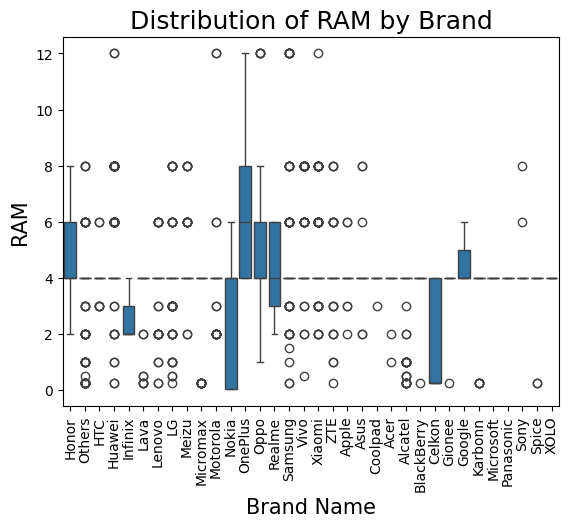

In [ ]:
sns.boxplot(df,x='brand_name',y='ram')
plt.xticks(rotation=90);
plt.xlabel('Brand Name',fontsize=15)
plt.ylabel('RAM',fontsize=15)
plt.title('Distribution of RAM by Brand',fontsize=18)
plt.show()


- The median RAM is 4 GB

### Distribution of Weight by Brand for Strong Battery Phones

In [ ]:
# Weight vary between brand names where battery is greater than 4500
#Create a new column "strong_battery" for phones with a a battery over 4500, yes=true. For phone with weaker battery, no=false
df['strong_battery'] = df['battery'].apply(lambda x: True if x > 4500 else False)
df.head()


,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price,strong_battery
0,Honor,Android,14.50,yes,no,13.0,5.0,64.0,3.0,3020.0,146.0,2020,127,4.307572,4.715100,False
1,Honor,Android,17.30,yes,yes,13.0,16.0,128.0,8.0,4300.0,213.0,2020,325,5.162097,5.519018,False
2,Honor,Android,16.69,yes,yes,13.0,8.0,128.0,8.0,4200.0,213.0,2020,162,5.111084,5.884631,False
3,Honor,Android,25.50,yes,yes,13.0,8.0,64.0,6.0,7250.0,480.0,2020,345,5.135387,5.630961,True
4,Honor,Android,15.32,yes,no,13.0,8.0,64.0,3.0,5000.0,185.0,2020,293,4.389995,4.947837,True


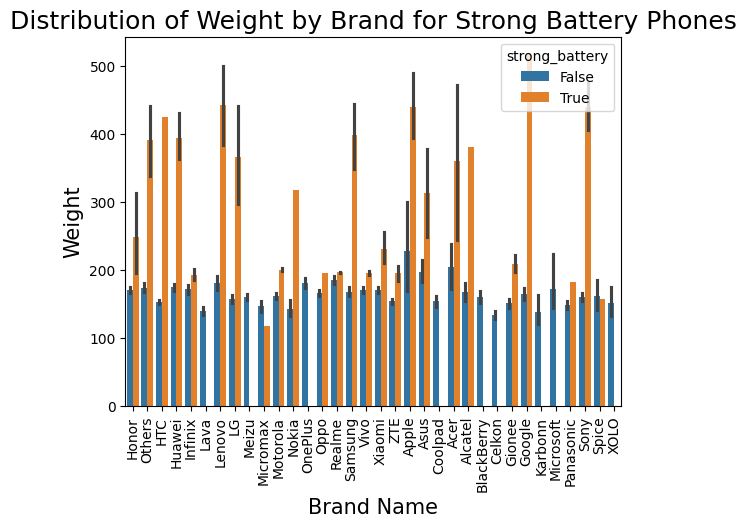

In [ ]:
# Graph to show distribution of brand an weight for strong battery phones
sns.barplot(df,x='brand_name',y='weight',hue='strong_battery')
plt.xticks(rotation=90)
plt.xlabel('Brand Name',fontsize=15)
plt.ylabel('Weight',fontsize=15)
plt.title('Distribution of Weight by Brand for Strong Battery Phones',fontsize=18)
plt.show()

- Phones with stronger batteries have a weight range of approximately 200 to 500 gram.
- All the phones with a weight above 200 gram, have batteries above 4500 mAh.

### Large screen phones

In [ ]:
# Create new column for large screen phones
df['large_screen'] = df['screen_size'].apply(lambda x: True if x > 6 else False)
df.head()

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price,strong_battery,large_screen
0,Honor,Android,14.50,yes,no,13.0,5.0,64.0,3.0,3020.0,146.0,2020,127,4.307572,4.715100,False,True
1,Honor,Android,17.30,yes,yes,13.0,16.0,128.0,8.0,4300.0,213.0,2020,325,5.162097,5.519018,False,True
2,Honor,Android,16.69,yes,yes,13.0,8.0,128.0,8.0,4200.0,213.0,2020,162,5.111084,5.884631,False,True
3,Honor,Android,25.50,yes,yes,13.0,8.0,64.0,6.0,7250.0,480.0,2020,345,5.135387,5.630961,True,True
4,Honor,Android,15.32,yes,no,13.0,8.0,64.0,3.0,5000.0,185.0,2020,293,4.389995,4.947837,True,True


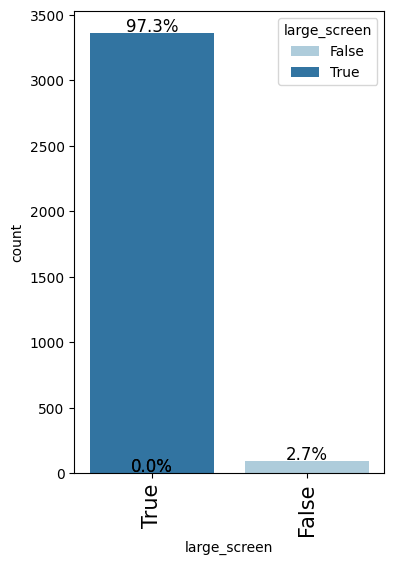

In [ ]:
# Show distribution of large screen phones by brand
labeled_barplot(df,"large_screen", perc=True)

In [ ]:
#
# Determine the count of large screen phones
df['large_screen'].value_counts()

,count
large_screen,
True,3362
False,92


- 97.3% of the total of 3454 brands are large screen phones, with a count of 3362

-

In [ ]:
df.groupby('brand_name')['large_screen'].sum()

,large_screen
brand_name,
Acer,51
Alcatel,115
Apple,39
Asus,122
BlackBerry,21
Celkon,25
Coolpad,22
Gionee,56
Google,15


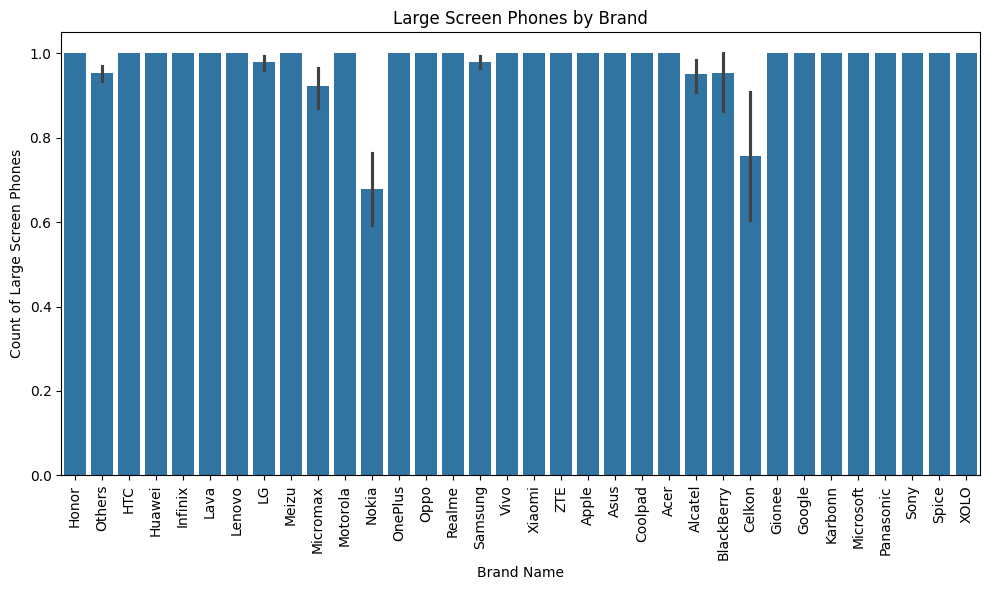

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='brand_name', y='large_screen')
plt.xticks(rotation=90)
plt.xlabel('Brand Name')
plt.ylabel('Count of Large Screen Phones')
plt.title('Large Screen Phones by Brand')
plt.tight_layout()
plt.show()



- The distribution of large screens are seen in most of the brand names.
- Nokia has the smallest large screen phone.

### Large selfie camera across brands

In [ ]:
#Create new column for large selfie camera across brands
df['large_selfie_cam'] = df['selfie_camera_mp'].apply(lambda x: True if x > 8 else False)
df.head()

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price,strong_battery,large_screen,large_selfie_cam
0,Honor,Android,14.50,yes,no,13.0,5.0,64.0,3.0,3020.0,146.0,2020,127,4.307572,4.715100,False,True,False
1,Honor,Android,17.30,yes,yes,13.0,16.0,128.0,8.0,4300.0,213.0,2020,325,5.162097,5.519018,False,True,True
2,Honor,Android,16.69,yes,yes,13.0,8.0,128.0,8.0,4200.0,213.0,2020,162,5.111084,5.884631,False,True,False
3,Honor,Android,25.50,yes,yes,13.0,8.0,64.0,6.0,7250.0,480.0,2020,345,5.135387,5.630961,True,True,False
4,Honor,Android,15.32,yes,no,13.0,8.0,64.0,3.0,5000.0,185.0,2020,293,4.389995,4.947837,True,True,False


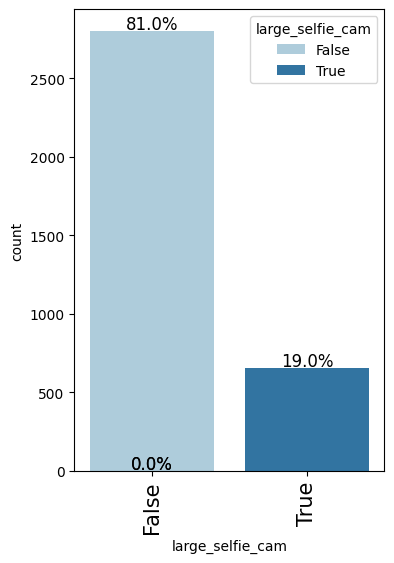

In [ ]:
# Show distribution of large selfie camera phones by brand
labeled_barplot(df,"large_selfie_cam", perc=True)

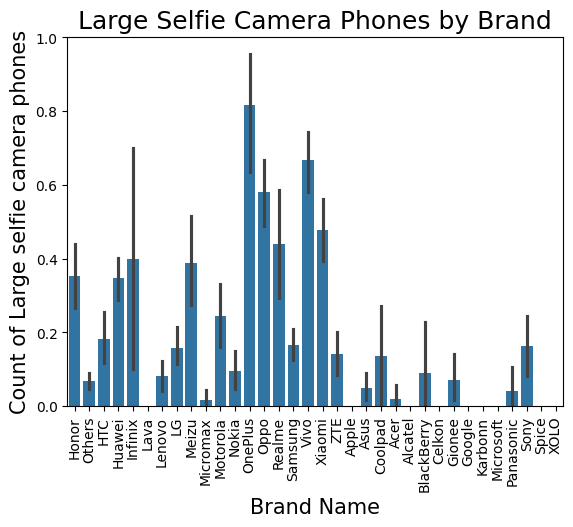

In [ ]:
sns.barplot(data=df, x='brand_name', y='large_selfie_cam')
plt.xticks(rotation=90)
plt.xlabel('Brand Name',fontsize=15)
plt.ylabel('Count of Large selfie camera phones',fontsize=15)
plt.title('Large Selfie Camera Phones by Brand',fontsize=18)
plt.show()

- The brands Oneplus, Vivo and Oppo has the top 3 largest selfie cameras.

### Highly correlated attributes with normalized price of used device

In [ ]:
#Determine the age of the phone by using the release year information
df['age'] = 2021 - df['release_year']
df.head()


,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price,strong_battery,large_screen,large_selfie_cam,age
0,Honor,Android,14.50,yes,no,13.0,5.0,64.0,3.0,3020.0,146.0,2020,127,4.307572,4.715100,False,True,False,1
1,Honor,Android,17.30,yes,yes,13.0,16.0,128.0,8.0,4300.0,213.0,2020,325,5.162097,5.519018,False,True,True,1
2,Honor,Android,16.69,yes,yes,13.0,8.0,128.0,8.0,4200.0,213.0,2020,162,5.111084,5.884631,False,True,False,1
3,Honor,Android,25.50,yes,yes,13.0,8.0,64.0,6.0,7250.0,480.0,2020,345,5.135387,5.630961,True,True,False,1
4,Honor,Android,15.32,yes,no,13.0,8.0,64.0,3.0,5000.0,185.0,2020,293,4.389995,4.947837,True,True,False,1


In [ ]:
#Create a correlation matrix to correlate the attributes with price of used devices
# creating a list of numerical columns
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print(num_cols)

# Drop release year
num_cols.remove('release_year')
print(num_cols)


['screen_size', 'main_camera_mp', 'selfie_camera_mp', 'int_memory', 'ram', 'battery', 'weight', 'release_year', 'days_used', 'normalized_used_price', 'normalized_new_price', 'age']
['screen_size', 'main_camera_mp', 'selfie_camera_mp', 'int_memory', 'ram', 'battery', 'weight', 'days_used', 'normalized_used_price', 'normalized_new_price', 'age']


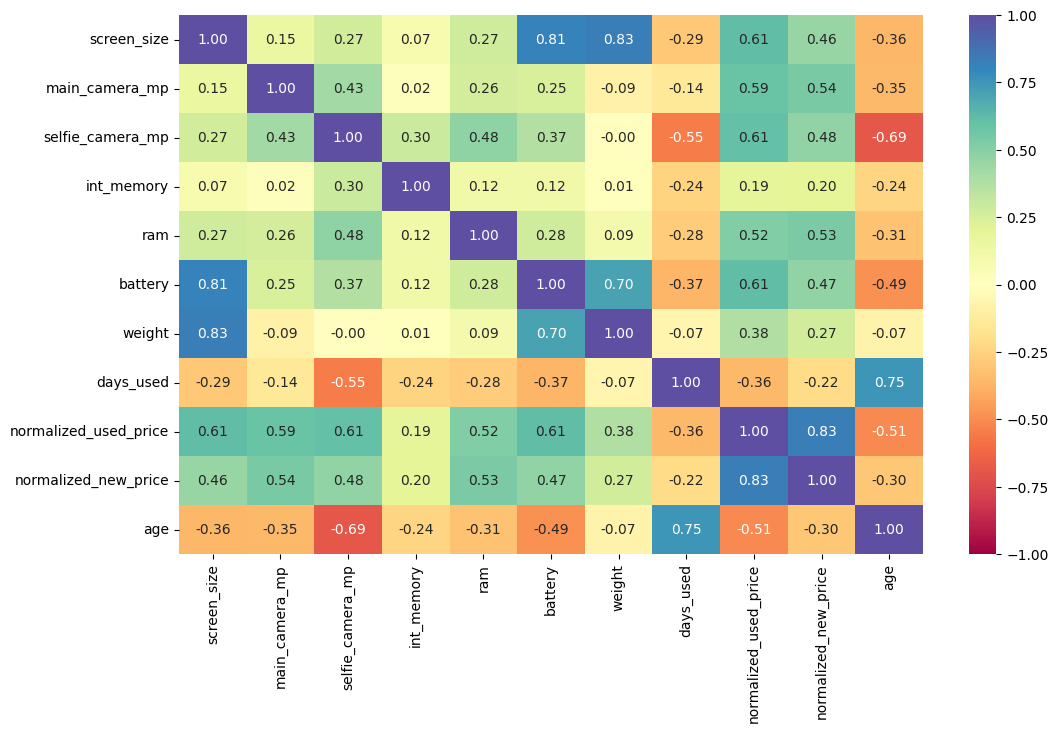

In [ ]:
# Plot heatmap
plt.figure(figsize=(12, 7))
sns.heatmap(
    df[num_cols].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()


- The only change in correlation between attributes and the normalized used price is a small change in the correlation between the price and main camera megapixels which was 0.59 before and 0.55 after data manipulation.


In [ ]:
df.head()

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price,strong_battery,large_screen,large_selfie_cam,age
0,Honor,Android,14.50,yes,no,13.0,5.0,64.0,3.0,3020.0,146.0,2020,127,4.307572,4.715100,False,True,False,1
1,Honor,Android,17.30,yes,yes,13.0,16.0,128.0,8.0,4300.0,213.0,2020,325,5.162097,5.519018,False,True,True,1
2,Honor,Android,16.69,yes,yes,13.0,8.0,128.0,8.0,4200.0,213.0,2020,162,5.111084,5.884631,False,True,False,1
3,Honor,Android,25.50,yes,yes,13.0,8.0,64.0,6.0,7250.0,480.0,2020,345,5.135387,5.630961,True,True,False,1
4,Honor,Android,15.32,yes,no,13.0,8.0,64.0,3.0,5000.0,185.0,2020,293,4.389995,4.947837,True,True,False,1


## Univariate analysis

In [ ]:
# Visualise with histogram_boxplot

### screen size

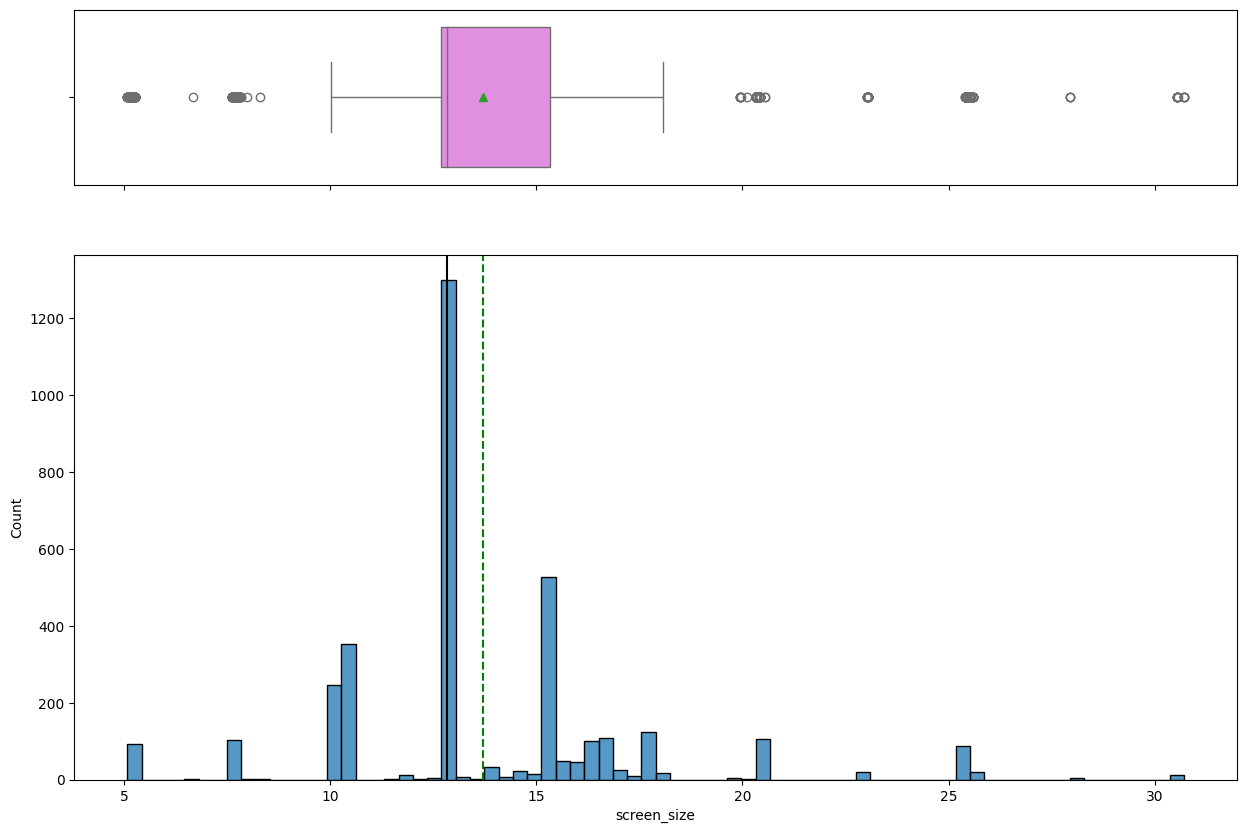

In [ ]:
histogram_boxplot(df, 'screen_size')

- Distribution of screen size is skewed to the right with a median of approximately 13 cm.

### 4G

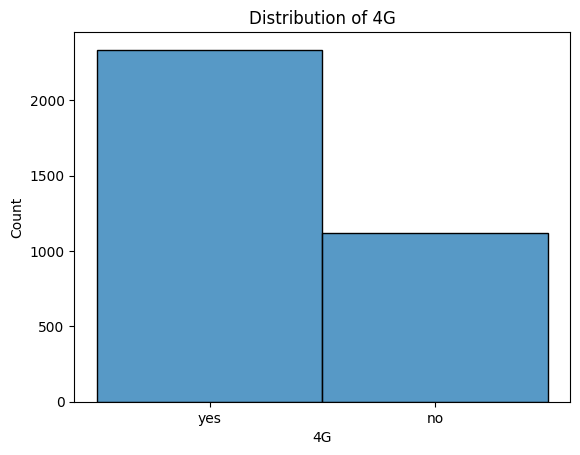

In [ ]:
sns.histplot(df, x='4g');
plt.xlabel('4G')
plt.ylabel('Count')
plt.title('Distribution of 4G')
plt.show()


- 4G is available in approximately 2400 phones

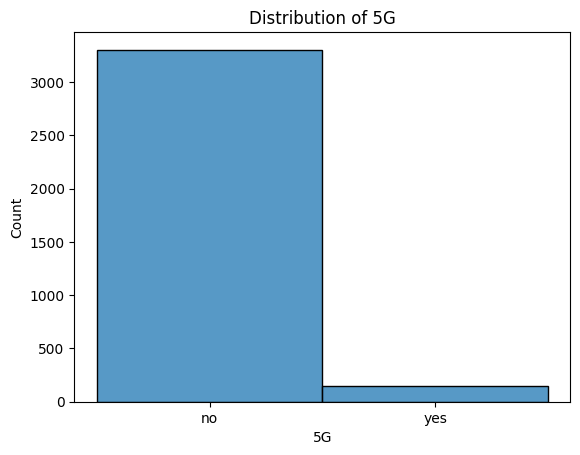

In [ ]:
sns.histplot(df, x='5g');
plt.xlabel('5G')
plt.ylabel('Count')
plt.title('Distribution of 5G')
plt.show()

- 5G is available in approximately 3400 phones

### main camera mp

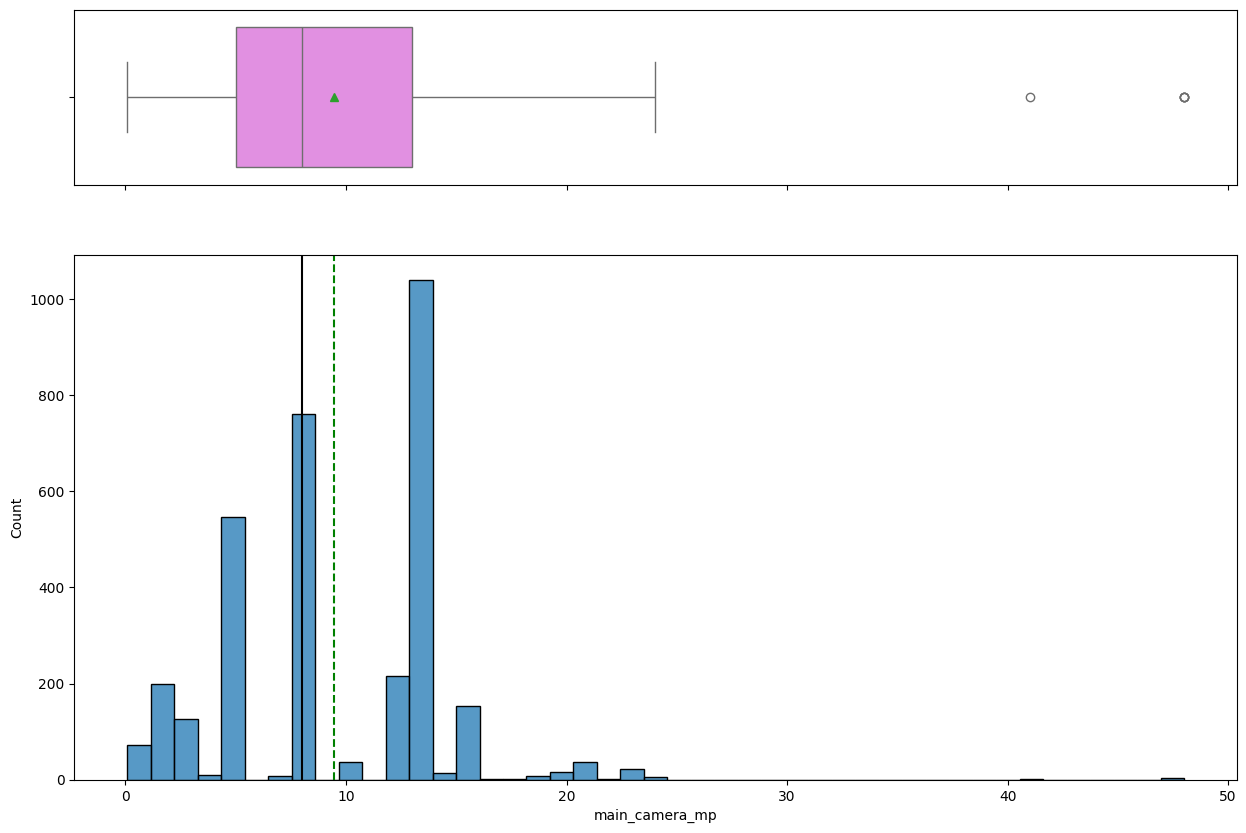

In [ ]:
histogram_boxplot(df, 'main_camera_mp')

- Main camera mp  distribution is skewed to the right with a median of about 8 mp.

### selfie camera mp

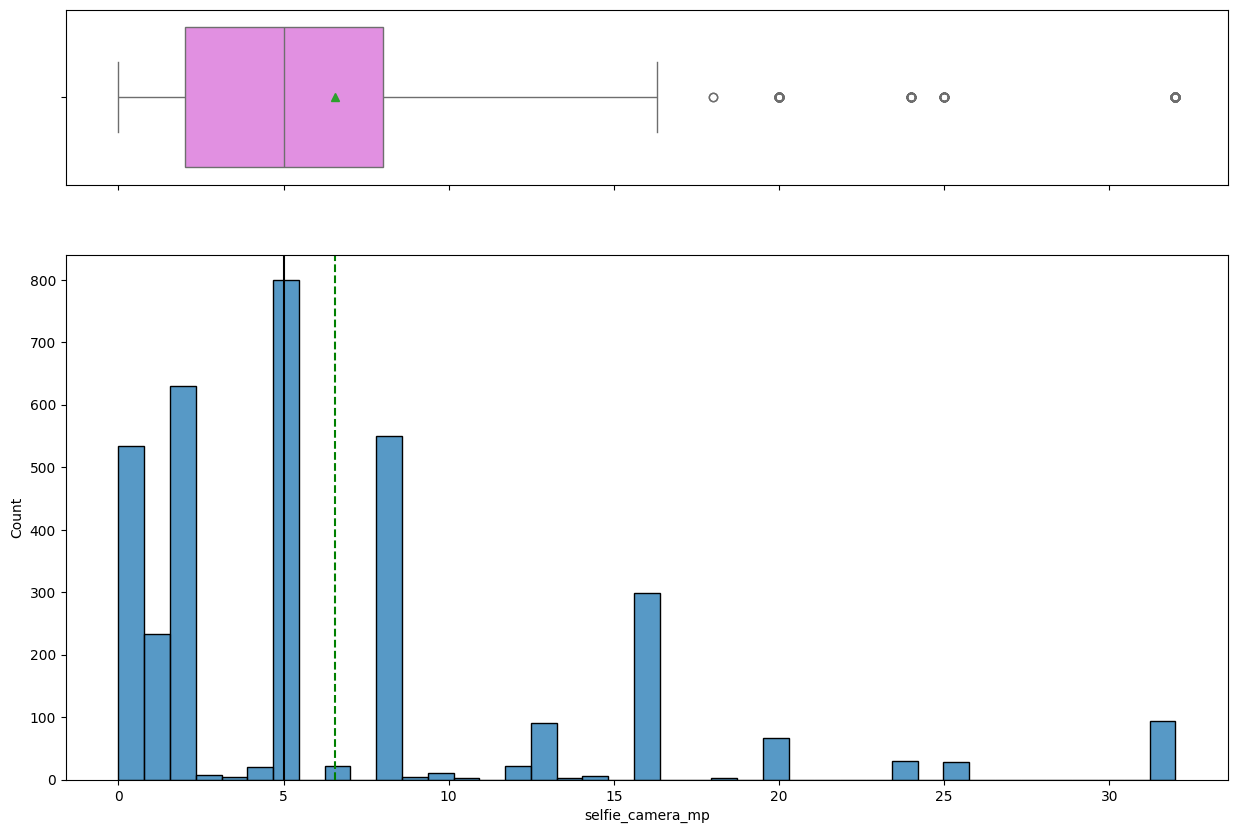

In [ ]:
histogram_boxplot(df, 'selfie_camera_mp')

- Selfie camera mp is skewed to the right.
- Median is 5 mp.

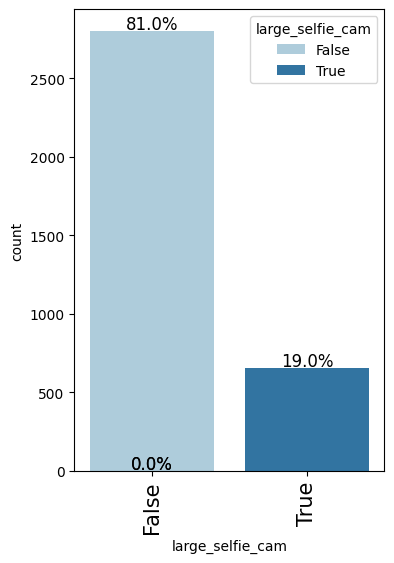

In [ ]:
labeled_barplot(df,"large_selfie_cam", perc=True)

- The 19% of phones have a large sefie camera (greater thatn 8 MP)

### battery

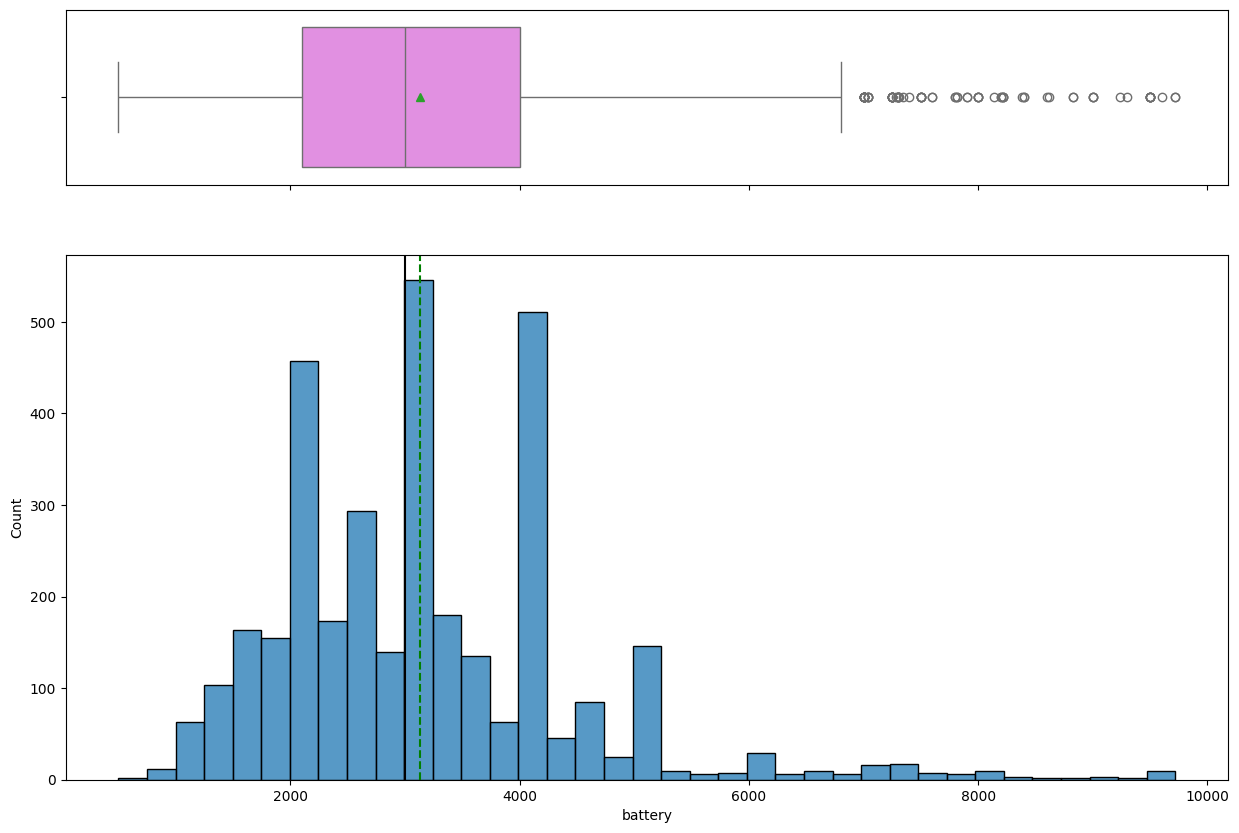

In [ ]:
histogram_boxplot(df, 'battery')

- Battery distribution is slightly skewed to the right with a median of about 3000 mAh.

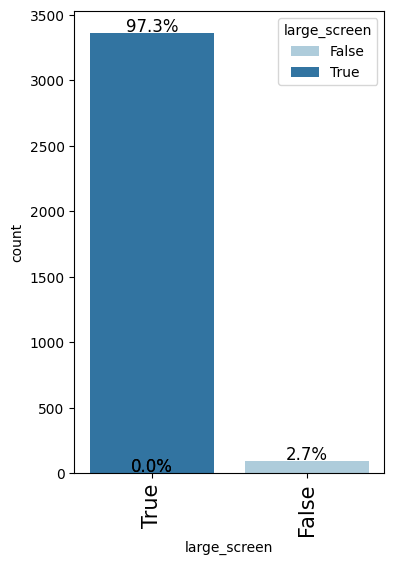

In [ ]:
labeled_barplot(df,"large_screen", perc=True)

- 97.3% of phones have large screens (Size bigger than 6 inches)

### internal memory

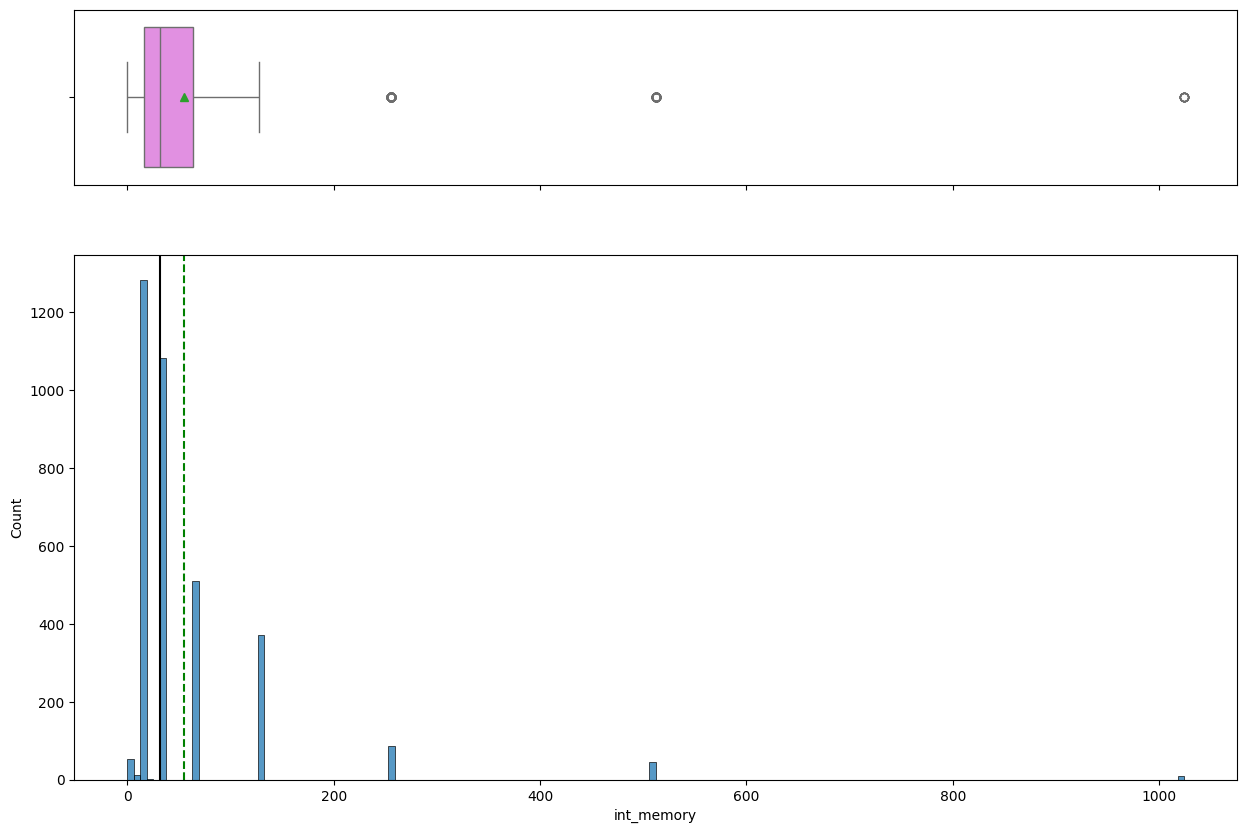

In [ ]:
histogram_boxplot(df, 'int_memory')

- The distribution of internal memory is skewed to the right with a median of about 30 GB.

### RAM

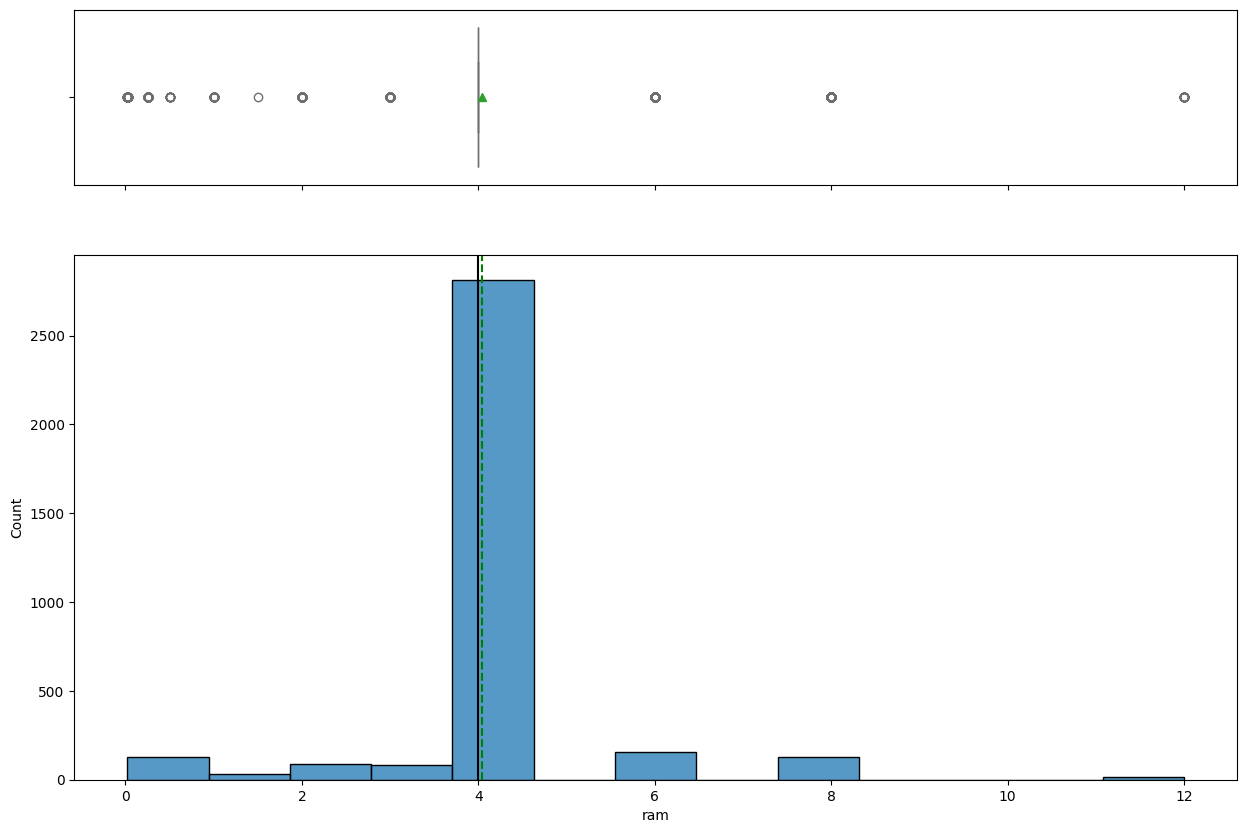

In [ ]:
histogram_boxplot(df, 'ram')

- RAM is a distribution with the both the median and mean value of 4 GB. Outliers are present.

### weight

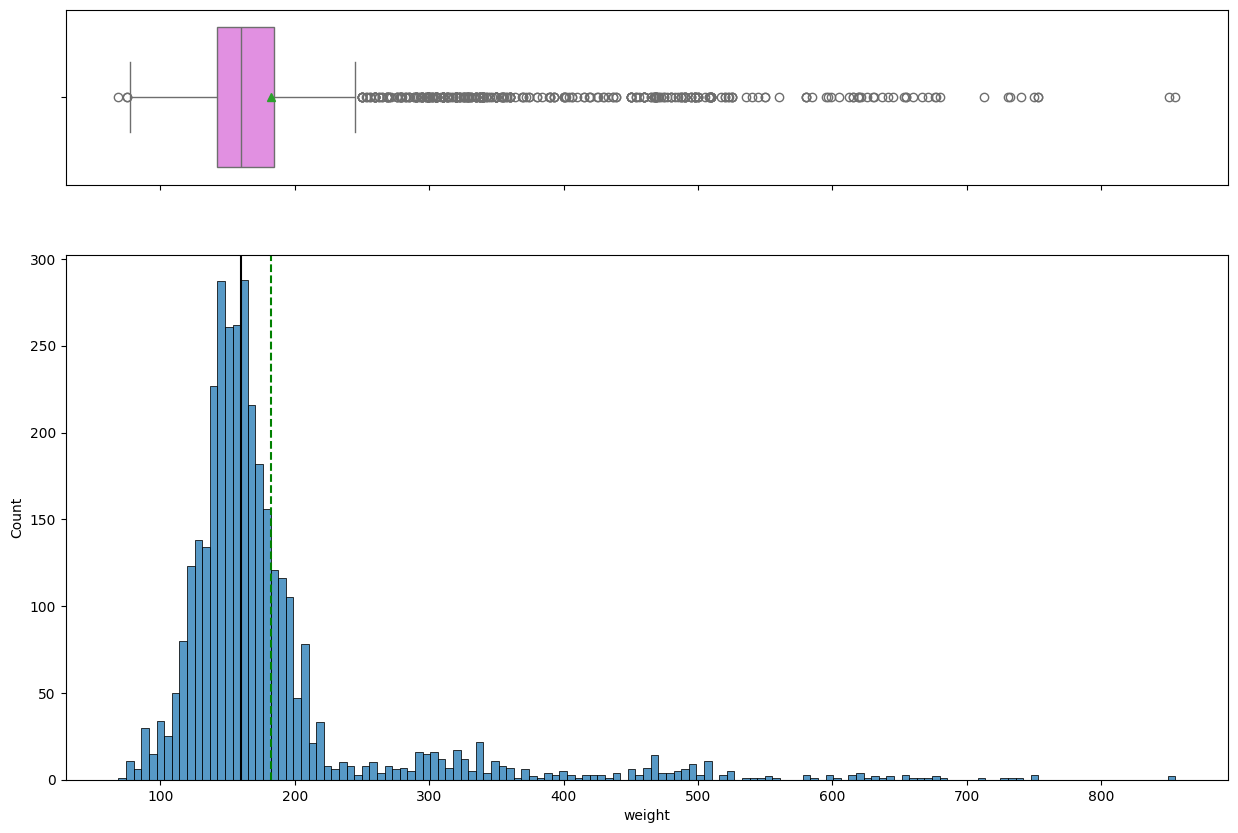

In [ ]:
histogram_boxplot(df, 'weight')

- Weight is extremely right skewed with a median of about 160 gram.

### age

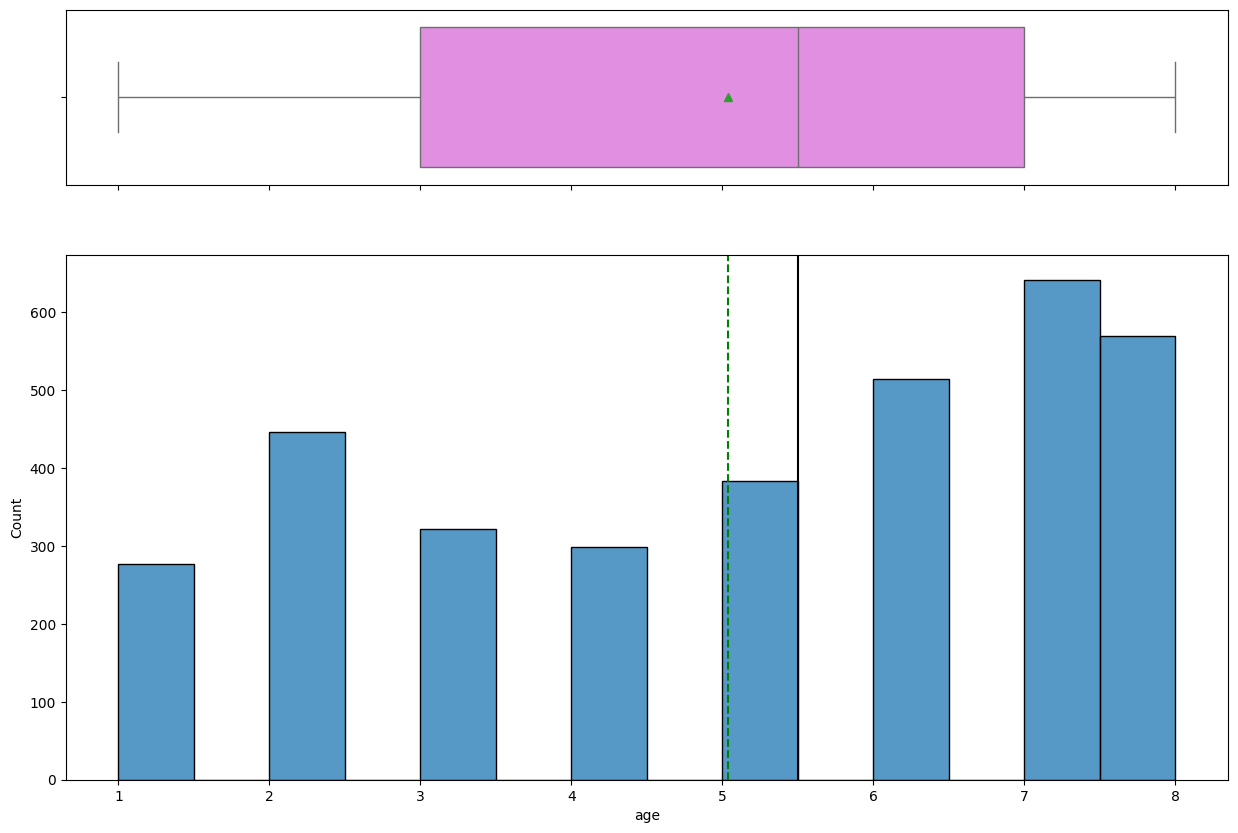

In [ ]:
histogram_boxplot(df, 'age')


- Age range is between 1 and 8 years.
- The distribution is heavily skewed to the left.
- The median age is 5.5 years.

### days used

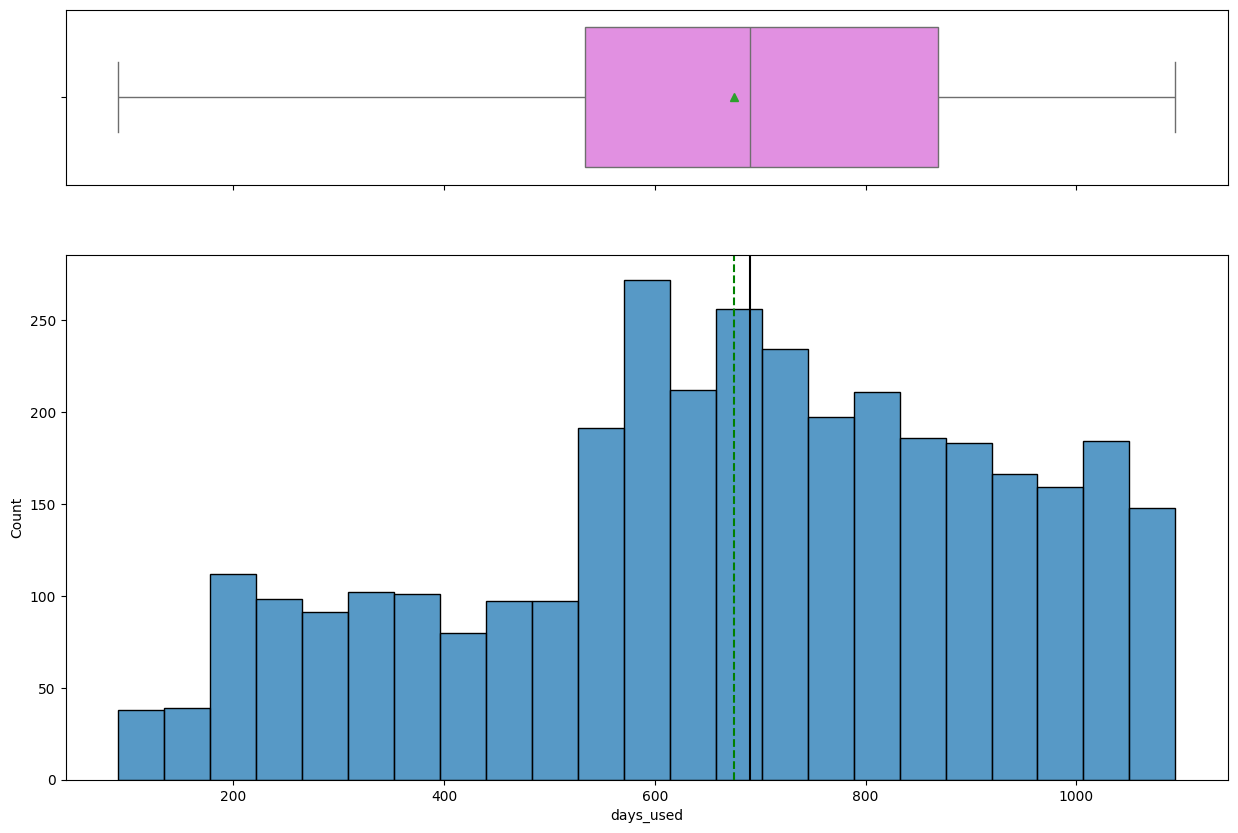

In [ ]:
histogram_boxplot(df, 'days_used')


- Days used distribution are skewed slightly to the left.

### normalized new price

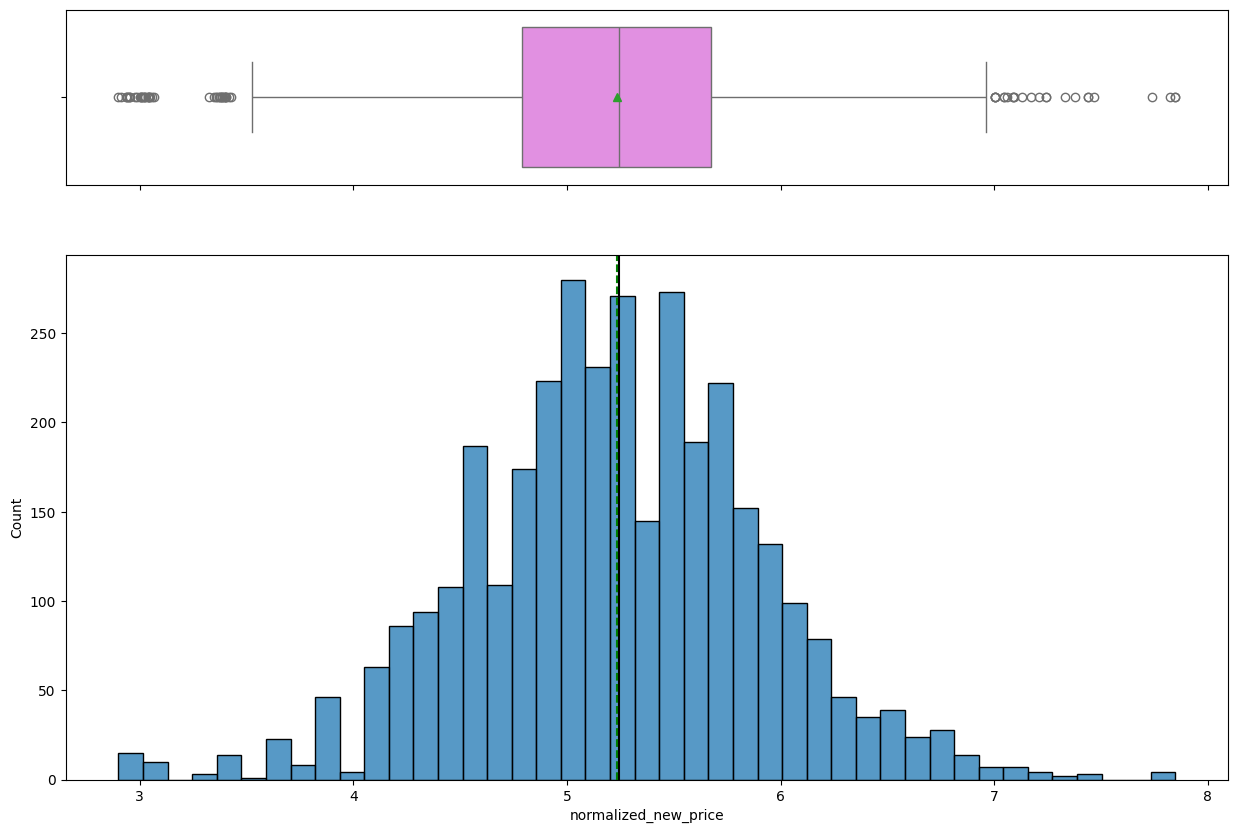

In [ ]:
histogram_boxplot(df, 'normalized_new_price')

- The new price is follows a normal distribution with a mean and median of about 5.3 Euros.

### normalised used price

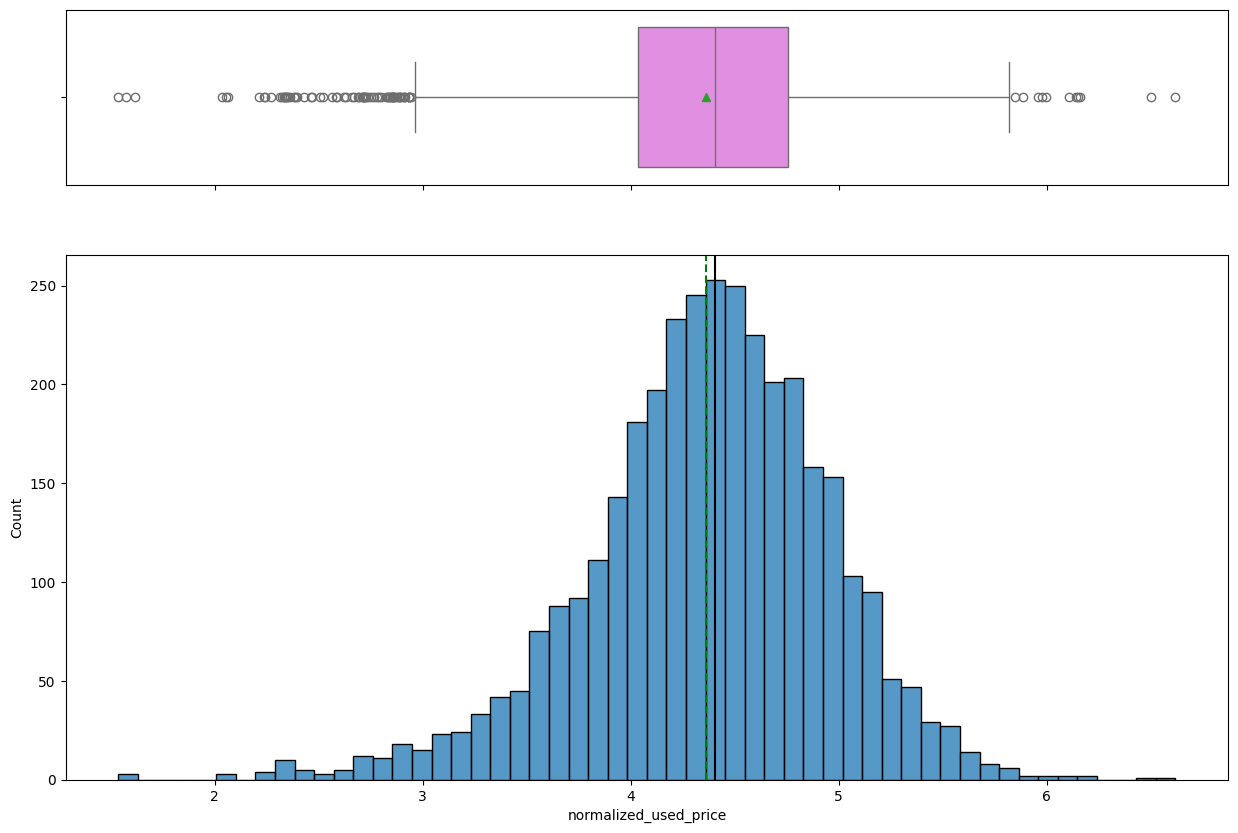

In [ ]:
histogram_boxplot(df, 'normalized_used_price')

- The normalized used price follows a normal distrinbution and is slightly skewed to the left.
- The median used price is about 4.3 euros.

## Multivariate analysis

### Used price versus screen size

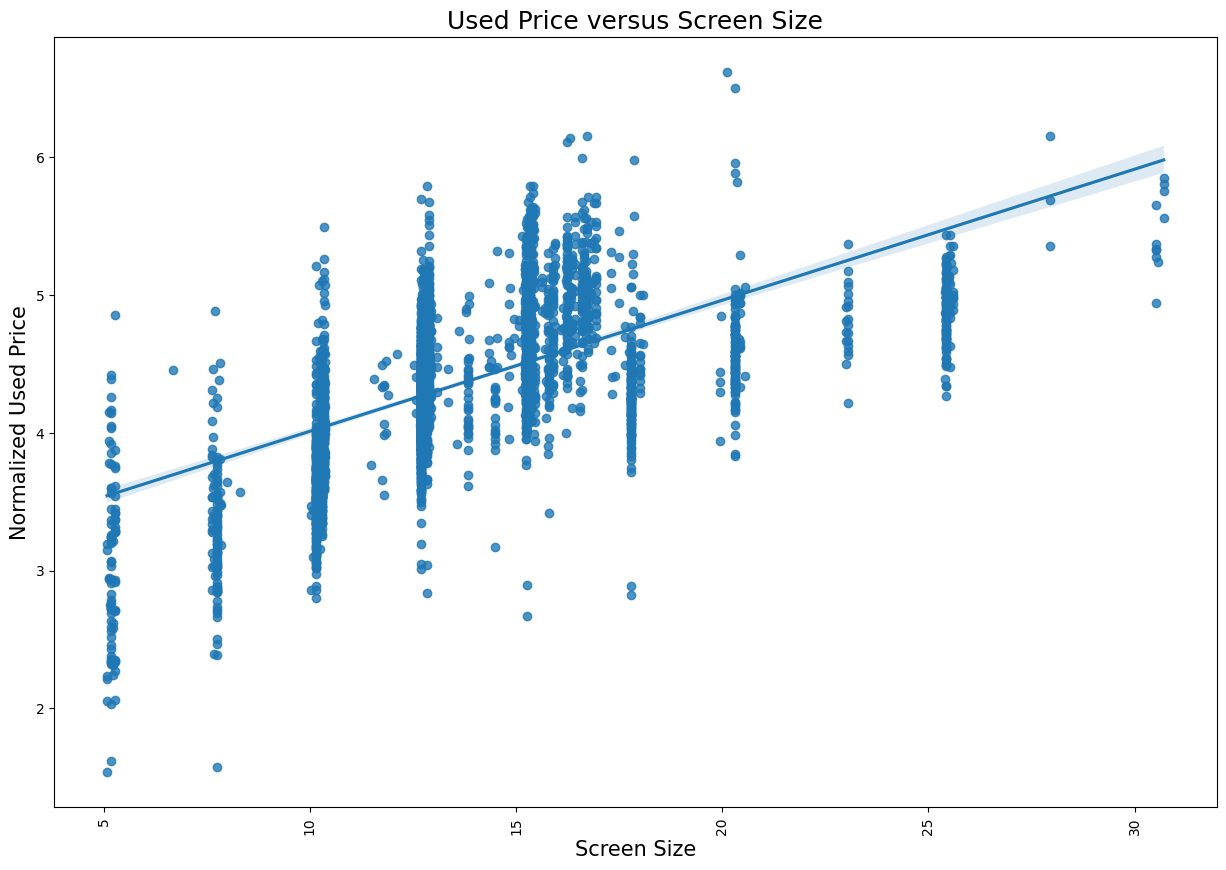

In [ ]:
figsize = (15, 10)
plt.figure(figsize=figsize)
sns.regplot(df,x='screen_size',y='normalized_used_price')
plt.xticks(rotation=90)
plt.xlabel('Screen Size',fontsize=15)
plt.ylabel('Normalized Used Price',fontsize=15)
plt.title('Used Price versus Screen Size',fontsize=18)
plt.show()

- The median price of 4.3 euros is clustered around the screen size of 15 to 20.
- A linear pattern is seen

### Normalized used price vs main camera mp

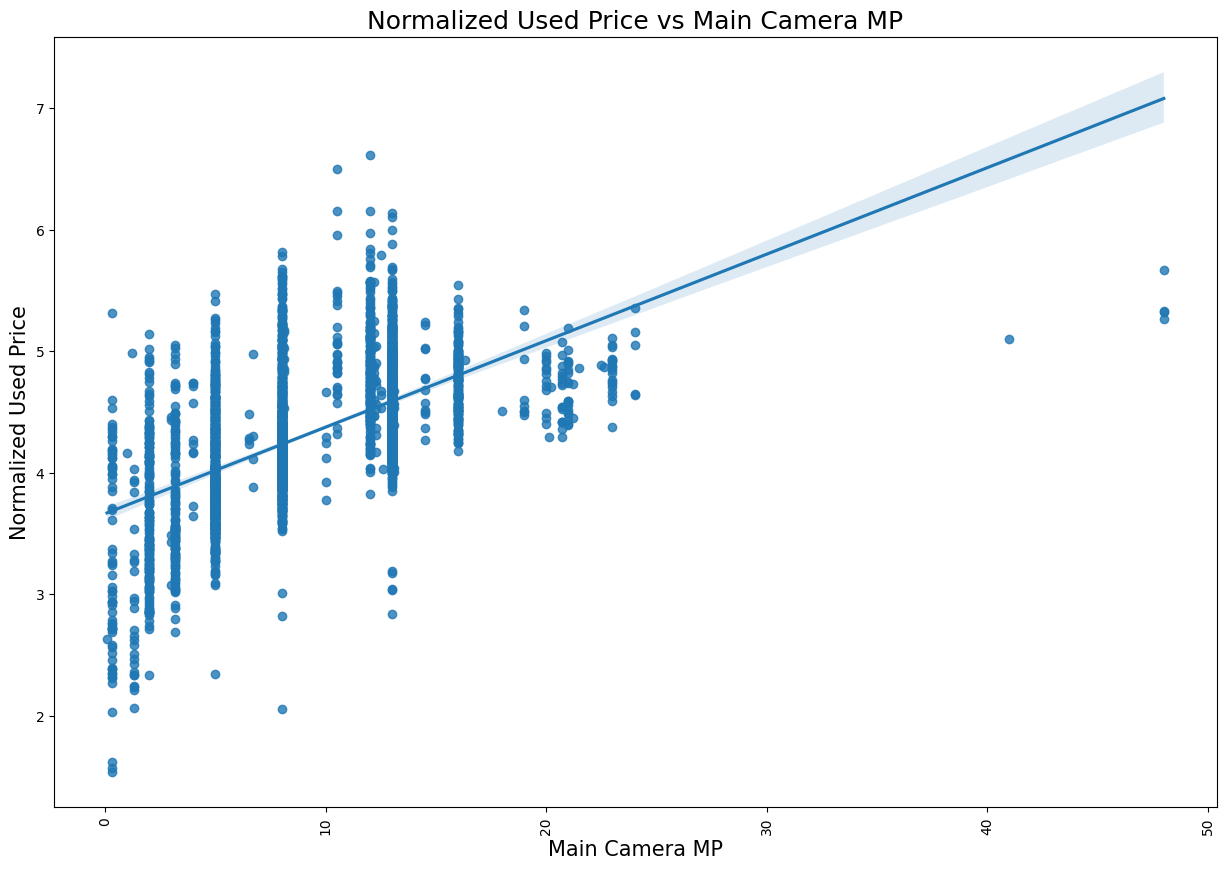

In [ ]:
figsize = (15, 10)
plt.figure(figsize=figsize)
sns.regplot(df,x='main_camera_mp',y='normalized_used_price')
plt.xticks(rotation=90)
plt.xlabel('Main Camera MP',fontsize=15)
plt.ylabel('Normalized Used Price',fontsize=15)
plt.title('Normalized Used Price vs Main Camera MP',fontsize=18)
plt.show()

- Normalized used price increases as the main camera mp increase up to about 10.5 mp.
- Increase of main camera megapixels above 10.5 mp do not seem to influence the used price.

- The devices mostly have a main camera between 0 and 25 megapixels.

### Normalized used price vs selfie camera mp

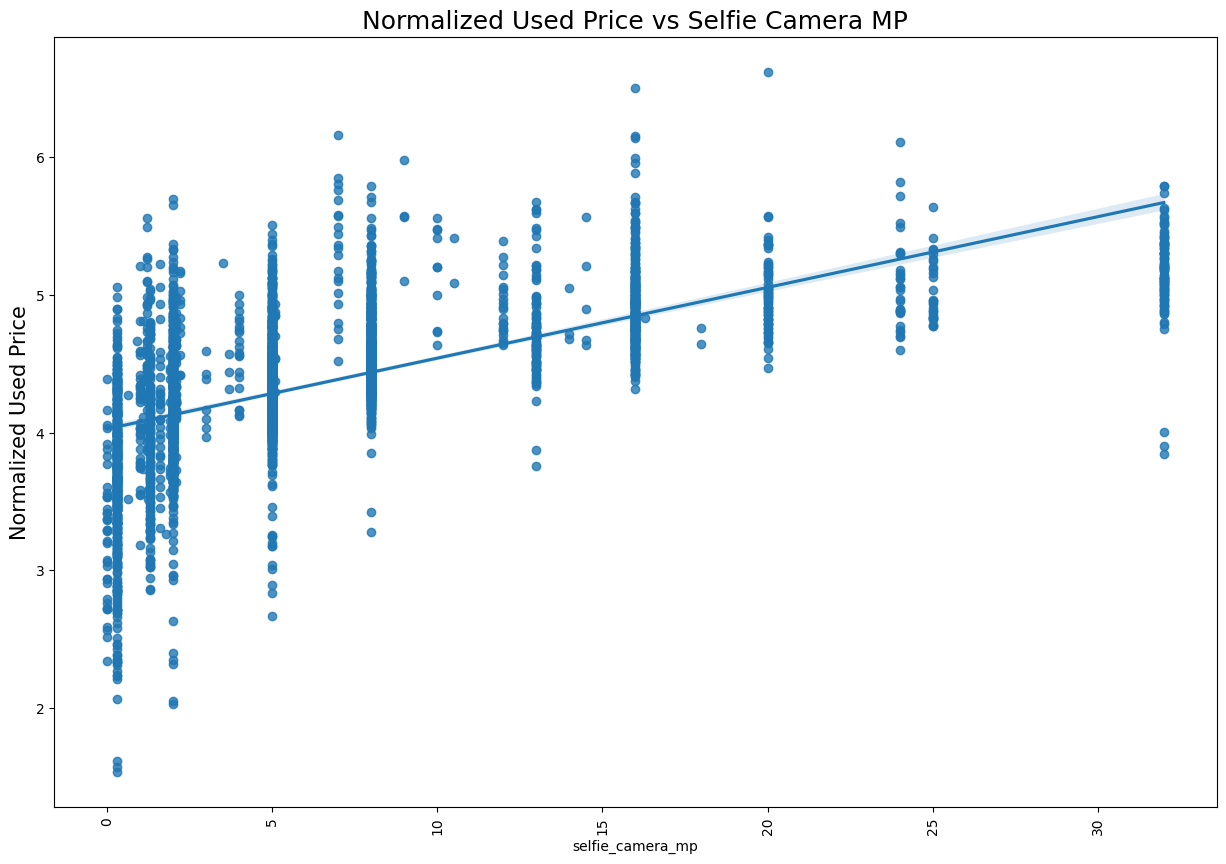

In [ ]:
figsize = (15, 10)
plt.figure(figsize=figsize)
sns.regplot(df,x='selfie_camera_mp',y='normalized_used_price')
plt.xticks(rotation=90)
#plt.xlabel('Selfie Camera MP',fontsize=15)
plt.ylabel('Normalized Used Price',fontsize=15)
plt.title('Normalized Used Price vs Selfie Camera MP',fontsize=18)
plt.show()

- Normalized used price increases as the selfie camera mp increases in a linear pattern

### Normalized used price vs battery

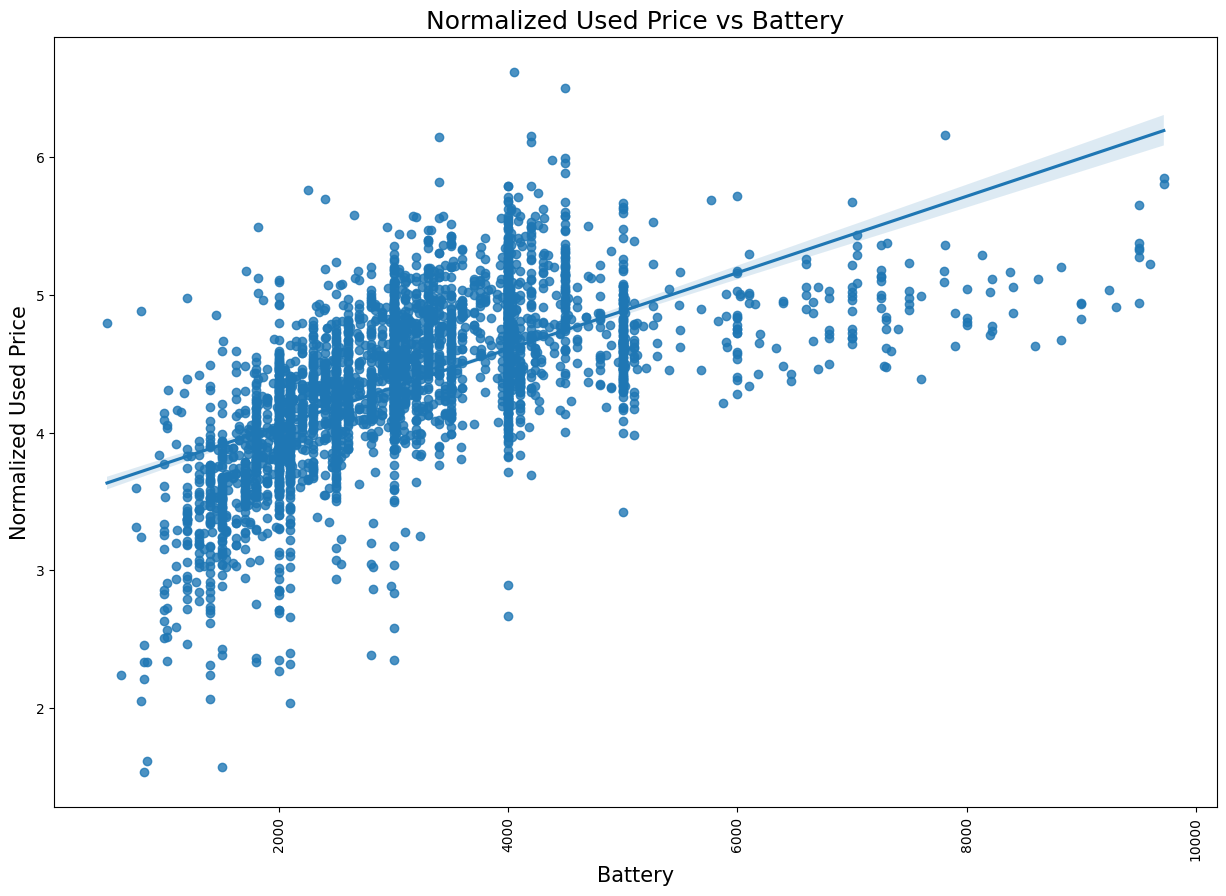

In [ ]:
figsize = (15, 10)
plt.figure(figsize=figsize)
sns.regplot(df,x='battery',y='normalized_used_price')
plt.xticks(rotation=90)
plt.xlabel('Battery',fontsize=15)
plt.ylabel('Normalized Used Price',fontsize=15)
plt.title('Normalized Used Price vs Battery',fontsize=18)
plt.show()

- Normalized used price increases as the battery capasity increases, up to about 4500 mAh.
- Above 4500 the size of the battery capasity does not seem to influence the price as much.

### Normalized used price vs RAM

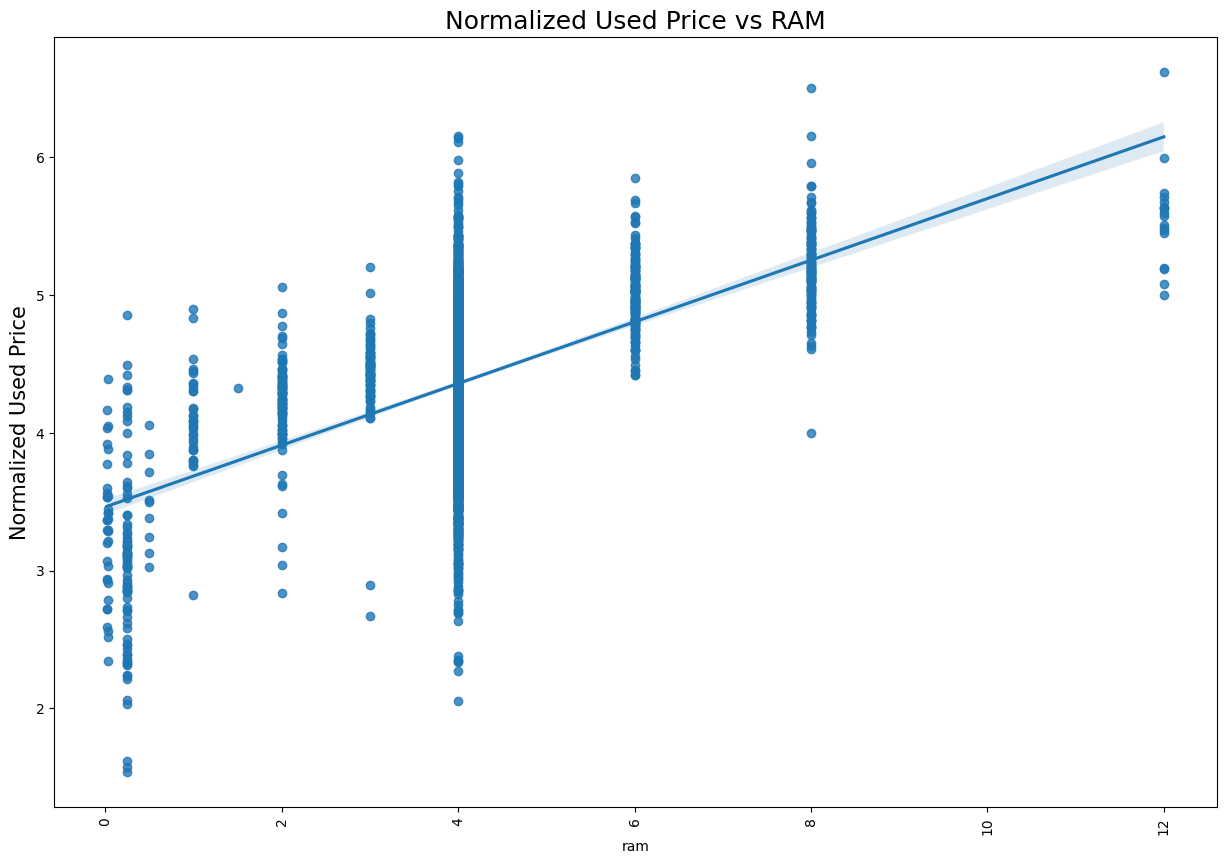

In [ ]:
figsize = (15, 10)
plt.figure(figsize=figsize)
sns.regplot(df,x='ram',y='normalized_used_price')
plt.xticks(rotation=90)
#plt.xlabel('RAM',fontsize=15)
plt.ylabel('Normalized Used Price',fontsize=15)
plt.title('Normalized Used Price vs RAM',fontsize=18)
plt.show()

- Normalized used price increases as RAM increases.

### Normalized used price vs age

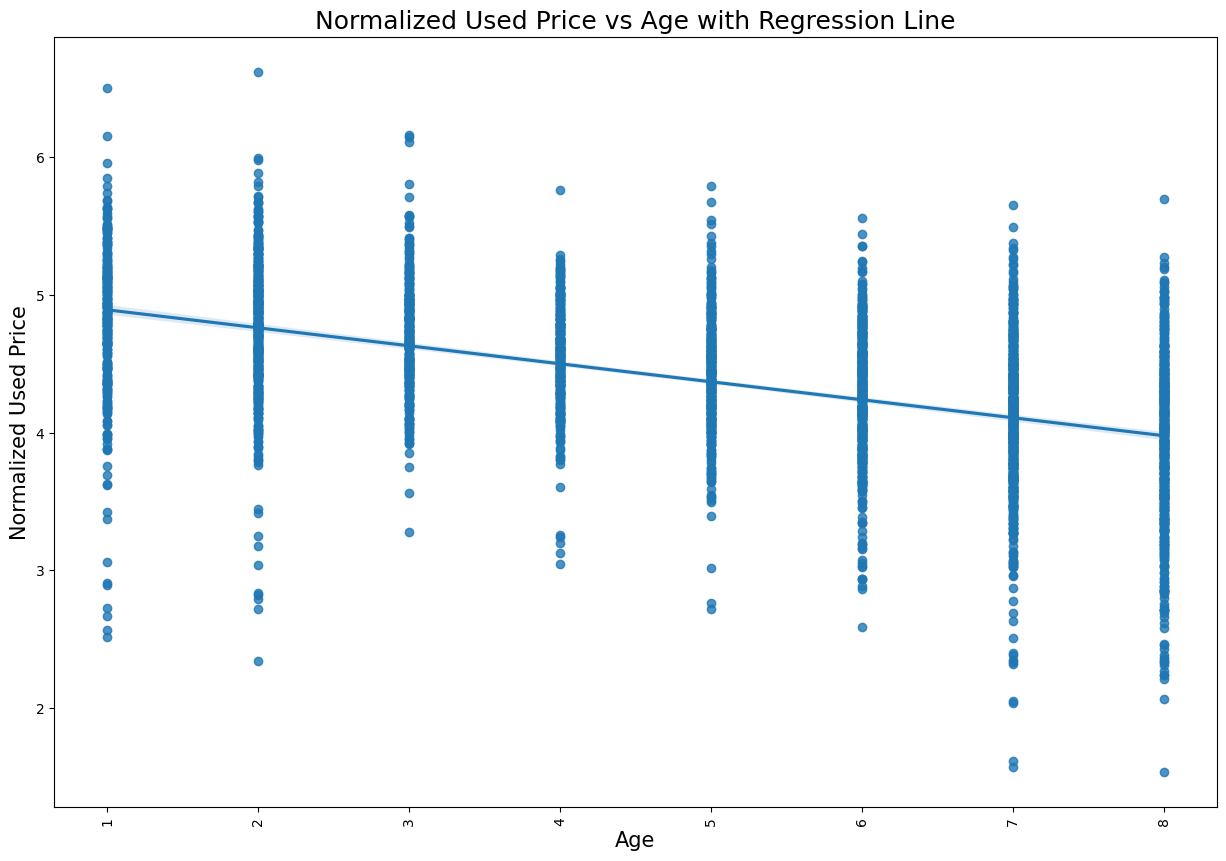

In [ ]:
figsize = (15, 10)
plt.figure(figsize=figsize)
sns.regplot(data=df, x='age', y='normalized_used_price')
plt.xticks(rotation=90)
plt.xlabel('Age', fontsize=15)
plt.ylabel('Normalized Used Price', fontsize=15)
plt.title('Normalized Used Price vs Age with Regression Line', fontsize=18)
plt.show()

- Normalized used price decreases as as age increases and it follows a linear distribution.

## Data Preprocessing

### Missing value treatment

In [ ]:
df.isnull().sum()

,0
brand_name,0
os,0
screen_size,0
4g,0
5g,0
main_camera_mp,179
selfie_camera_mp,2
int_memory,4
ram,4
battery,6


In [ ]:
# Copy original data
df1=df.copy()



In [ ]:
# Use median of the main_camera_mp column to replace missing values since the distribution is skewed to the right
df1['main_camera_mp']=df1['main_camera_mp'].fillna(df1['main_camera_mp'].median())

In [ ]:
# Use median of the selfie_camera_mp column to replace missing values since the distribution is skewed to the right
df1['selfie_camera_mp']=df1['selfie_camera_mp'].fillna(df1['selfie_camera_mp'].median())

In [ ]:
# Use median of the internal memory column to replace missing values since the distribution is skewed to the right
df1['int_memory']=df1['int_memory'].fillna(df1['int_memory'].median())

In [ ]:
# Use median of the ram to replace missing values since the distribution is
df1['int_memory']=df1['int_memory'].fillna(df1['int_memory'].median())

In [ ]:
# Use median of the ram column to replace missing values since outliers are present
df1['ram']=df1['ram'].fillna(df1['ram'].median())

In [ ]:
# Use median of the battery column to replace missing values since distribution are skewed to the right
df1['battery']=df1['battery'].fillna(df1['battery'].median())

In [ ]:
# Use median of the weight column to replace missing values since distribution are skewed to the right
df1['weight']=df1['weight'].fillna(df1['weight'].median())

In [ ]:
#recheck for missing values
df1.isnull().sum()

,0
brand_name,0
os,0
screen_size,0
4g,0
5g,0
main_camera_mp,0
selfie_camera_mp,0
int_memory,0
ram,0
battery,0


- All missing values have been treated.

### Outlier detection

In [ ]:
#outlier detection numeric columns
num_cols = df1.select_dtypes(include=np.number).columns.tolist()
print(num_cols)

['screen_size', 'main_camera_mp', 'selfie_camera_mp', 'int_memory', 'ram', 'battery', 'weight', 'release_year', 'days_used', 'normalized_used_price', 'normalized_new_price', 'age']


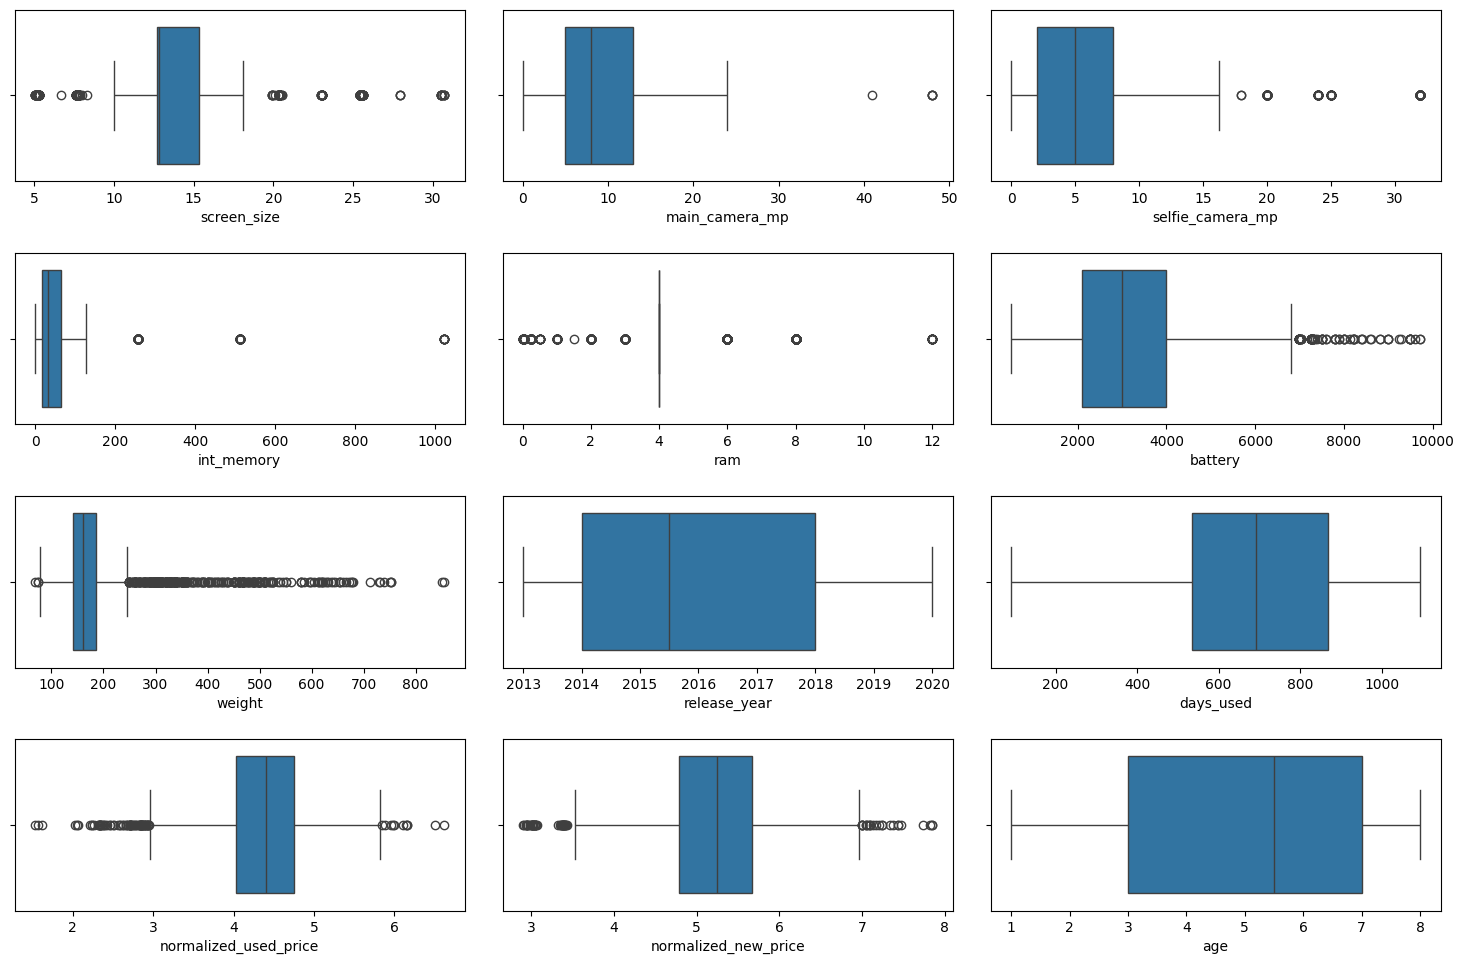

In [ ]:
#Use boxplots
plt.figure(figsize=(15, 10))

# Adjust the subplot grid to accommodate all variables
num_rows = 4  # number of rows
num_cols_grid = 3  # Number of columns in the grid

for i, variable in enumerate(num_cols):
    plt.subplot(num_rows, num_cols_grid, i + 1)  # Adjusted subplot layout
    sns.boxplot(data=df1, x=variable)
    plt.tight_layout(pad=2)

plt.show()

- There are a lot of outliers in the data
- The outliers will not be treated
- Drop release year, since age has replaced this column as a numerical value.


In [ ]:
df1.drop('release_year', axis=1, inplace=True)

### Preparing data for modeling

- The aim is to predict the normalized used price of a device


In [ ]:
#Define X and y variables
X = df1.drop(['normalized_used_price'], axis=1)
y = df1['normalized_used_price']
print(X.head())
print(y.head())

  brand_name       os  screen_size   4g   5g  main_camera_mp  \
0      Honor  Android        14.50  yes   no            13.0   
1      Honor  Android        17.30  yes  yes            13.0   
2      Honor  Android        16.69  yes  yes            13.0   
3      Honor  Android        25.50  yes  yes            13.0   
4      Honor  Android        15.32  yes   no            13.0   

   selfie_camera_mp  int_memory  ram  battery  weight  days_used  \
0               5.0        64.0  3.0   3020.0   146.0        127   
1              16.0       128.0  8.0   4300.0   213.0        325   
2               8.0       128.0  8.0   4200.0   213.0        162   
3               8.0        64.0  6.0   7250.0   480.0        345   
4               8.0        64.0  3.0   5000.0   185.0        293   

   normalized_new_price  strong_battery  large_screen  large_selfie_cam  age  
0              4.715100           False          True             False    1  
1              5.519018           False         

In [ ]:
# add intercept to data
X = sm.add_constant(X)
X.head()


,const,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,days_used,normalized_new_price,strong_battery,large_screen,large_selfie_cam,age
0,1.0,Honor,Android,14.50,yes,no,13.0,5.0,64.0,3.0,3020.0,146.0,127,4.715100,False,True,False,1
1,1.0,Honor,Android,17.30,yes,yes,13.0,16.0,128.0,8.0,4300.0,213.0,325,5.519018,False,True,True,1
2,1.0,Honor,Android,16.69,yes,yes,13.0,8.0,128.0,8.0,4200.0,213.0,162,5.884631,False,True,False,1
3,1.0,Honor,Android,25.50,yes,yes,13.0,8.0,64.0,6.0,7250.0,480.0,345,5.630961,True,True,False,1
4,1.0,Honor,Android,15.32,yes,no,13.0,8.0,64.0,3.0,5000.0,185.0,293,4.947837,True,True,False,1


In [ ]:
# Check if 'brand_name' column exists in df1
print(df1.columns)

# If 'brand_name' is not present, it might have been dropped accidentally.
# You need to recreate df1 from the original data (df) or add it back if it was renamed.

# Assuming 'brand_name' was dropped, recreate df1:
df1 = df.copy() # Assuming df is your original DataFrame

# proceed to create dummy variables
brand_dummies = pd.get_dummies(df1['brand_name'], prefix='brand')

# add these dummy columns to your original dataframe:
df1_with_dummies = pd.concat([df1, brand_dummies], axis=1) # Changed df to df1

# drop the original brand_name column:
df1_with_dummies = df1_with_dummies.drop('brand_name', axis=1) # Changed df_with_dummies to df1_with_dummies

Index(['brand_name', 'os', 'screen_size', '4g', '5g', 'main_camera_mp',
       'selfie_camera_mp', 'int_memory', 'ram', 'battery', 'weight',
       'days_used', 'normalized_used_price', 'normalized_new_price',
       'strong_battery', 'large_screen', 'large_selfie_cam', 'age'],
      dtype='object')


In [ ]:
# Create dummy variables
X= pd.get_dummies(X,columns=X.select_dtypes(include=['object','category']).columns.tolist(),drop_first=True)
X.head()

,const,screen_size,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,days_used,normalized_new_price,...,brand_name_Spice,brand_name_Vivo,brand_name_XOLO,brand_name_Xiaomi,brand_name_ZTE,os_Others,os_Windows,os_iOS,4g_yes,5g_yes
0,1.0,14.50,13.0,5.0,64.0,3.0,3020.0,146.0,127,4.715100,...,False,False,False,False,False,False,False,False,True,False
1,1.0,17.30,13.0,16.0,128.0,8.0,4300.0,213.0,325,5.519018,...,False,False,False,False,False,False,False,False,True,True
2,1.0,16.69,13.0,8.0,128.0,8.0,4200.0,213.0,162,5.884631,...,False,False,False,False,False,False,False,False,True,True
3,1.0,25.50,13.0,8.0,64.0,6.0,7250.0,480.0,345,5.630961,...,False,False,False,False,False,False,False,False,True,True
4,1.0,15.32,13.0,8.0,64.0,3.0,5000.0,185.0,293,4.947837,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
# Convert into float for modeling
X = X.astype(float)
X.head()

,const,screen_size,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,days_used,normalized_new_price,...,brand_name_Spice,brand_name_Vivo,brand_name_XOLO,brand_name_Xiaomi,brand_name_ZTE,os_Others,os_Windows,os_iOS,4g_yes,5g_yes
0,1.0,14.50,13.0,5.0,64.0,3.0,3020.0,146.0,127.0,4.715100,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.0,17.30,13.0,16.0,128.0,8.0,4300.0,213.0,325.0,5.519018,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,1.0,16.69,13.0,8.0,128.0,8.0,4200.0,213.0,162.0,5.884631,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
3,1.0,25.50,13.0,8.0,64.0,6.0,7250.0,480.0,345.0,5.630961,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4,1.0,15.32,13.0,8.0,64.0,3.0,5000.0,185.0,293.0,4.947837,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
# splitting the data in 70:30 ratio for train to test data

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)
print("Number of rows in train data =", x_train.shape[0])
print("Number of rows in test data =", x_test.shape[0])

Number of rows in train data = 2417
Number of rows in test data = 1037


## EDA

- It is a good idea to explore the data once again after manipulating it.

In [ ]:
# Understanding datatypes
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3454 entries, 0 to 3453
Data columns (total 52 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   const                  3454 non-null   float64
 1   screen_size            3454 non-null   float64
 2   main_camera_mp         3454 non-null   float64
 3   selfie_camera_mp       3454 non-null   float64
 4   int_memory             3454 non-null   float64
 5   ram                    3454 non-null   float64
 6   battery                3454 non-null   float64
 7   weight                 3454 non-null   float64
 8   days_used              3454 non-null   float64
 9   normalized_new_price   3454 non-null   float64
 10  strong_battery         3454 non-null   float64
 11  large_screen           3454 non-null   float64
 12  large_selfie_cam       3454 non-null   float64
 13  age                    3454 non-null   float64
 14  brand_name_Alcatel     3454 non-null   float64
 15  bran

- All data is a float datatype and there are no missing values.

In [ ]:
# Descriptive statistics after manupilating data
df1.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
brand_name,3454,34,Others,502,NaN,NaN,NaN,NaN,NaN,NaN,NaN
os,3454,4,Android,3214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
screen_size,3454.0,NaN,NaN,NaN,13.713115,3.80528,5.08,12.7,12.83,15.34,30.71
4g,3454,2,yes,2335,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5g,3454,2,no,3302,NaN,NaN,NaN,NaN,NaN,NaN,NaN
main_camera_mp,3275.0,NaN,NaN,NaN,9.460208,4.815461,0.08,5.0,8.0,13.0,48.0
selfie_camera_mp,3452.0,NaN,NaN,NaN,6.554229,6.970372,0.0,2.0,5.0,8.0,32.0
int_memory,3450.0,NaN,NaN,NaN,54.573099,84.972371,0.01,16.0,32.0,64.0,1024.0
ram,3450.0,NaN,NaN,NaN,4.036122,1.365105,0.02,4.0,4.0,4.0,12.0
battery,3448.0,NaN,NaN,NaN,3133.402697,1299.682844,500.0,2100.0,3000.0,4000.0,9720.0


- The main camera average megapixels are 9.38 after replacing mssing values with the median vs 9.56 mp in the initial EDA.
- Selfie camera, internal memory, ram battery and weight average values are unchanged after treating missing data.


In [ ]:
X.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
const,3454.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
screen_size,3454.0,13.713115,3.805280,5.080000,12.700000,12.830000,15.340000,30.710000
main_camera_mp,3454.0,9.384534,4.700148,0.080000,5.000000,8.000000,13.000000,48.000000
selfie_camera_mp,3454.0,6.553329,6.968453,0.000000,2.000000,5.000000,8.000000,32.000000
int_memory,3454.0,54.546957,84.926611,0.010000,16.000000,32.000000,64.000000,1024.000000
ram,3454.0,4.036080,1.364314,0.020000,4.000000,4.000000,4.000000,12.000000
battery,3454.0,3133.170961,1298.565062,500.000000,2100.000000,3000.000000,4000.000000,9720.000000
weight,3454.0,182.705761,88.329494,69.000000,142.000000,160.000000,185.000000,855.000000
days_used,3454.0,674.869716,248.580166,91.000000,533.500000,690.500000,868.750000,1094.000000
normalized_new_price,3454.0,5.233107,0.683637,2.901422,4.790342,5.245892,5.673718,7.847841


- The mean days used are 675.
- The mean age of devices are 5.03 years, ranging from 1.00 to	8.00 years.
- Mean normalized new price of 5.3 Euros
- 9.9% of devices have a strong battery
- 97.3% of devices have a large screen
- 19% have a large selfie cam

This corellates with the initial EDA.

### Review of initial analysis

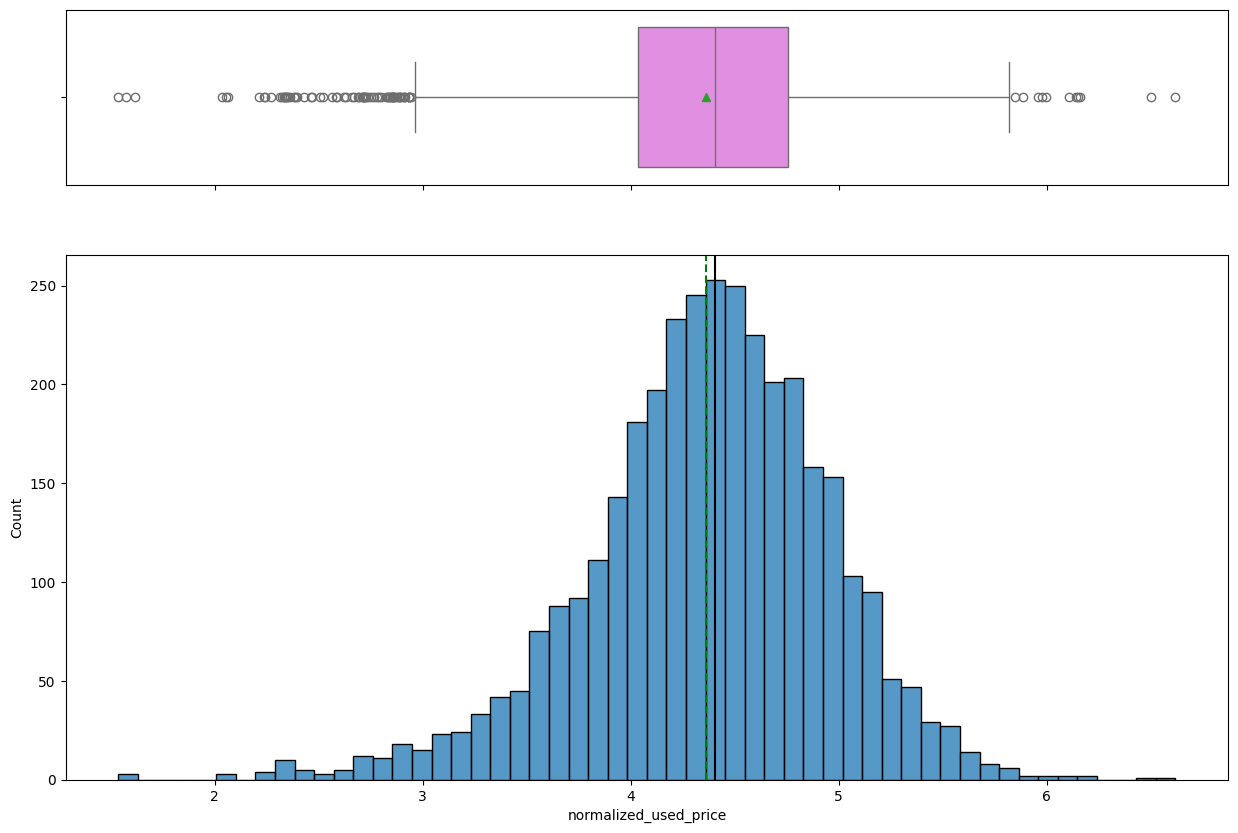

In [ ]:
# Histogram_boxplot of normalized used prices
histogram_boxplot(df1, 'normalized_used_price')

- The distribution curve is unchanged from initial EDA, with median of about 4.4 Euros


['screen_size', 'main_camera_mp', 'selfie_camera_mp', 'int_memory', 'ram', 'battery', 'weight', 'release_year', 'days_used', 'normalized_used_price', 'normalized_new_price', 'age']


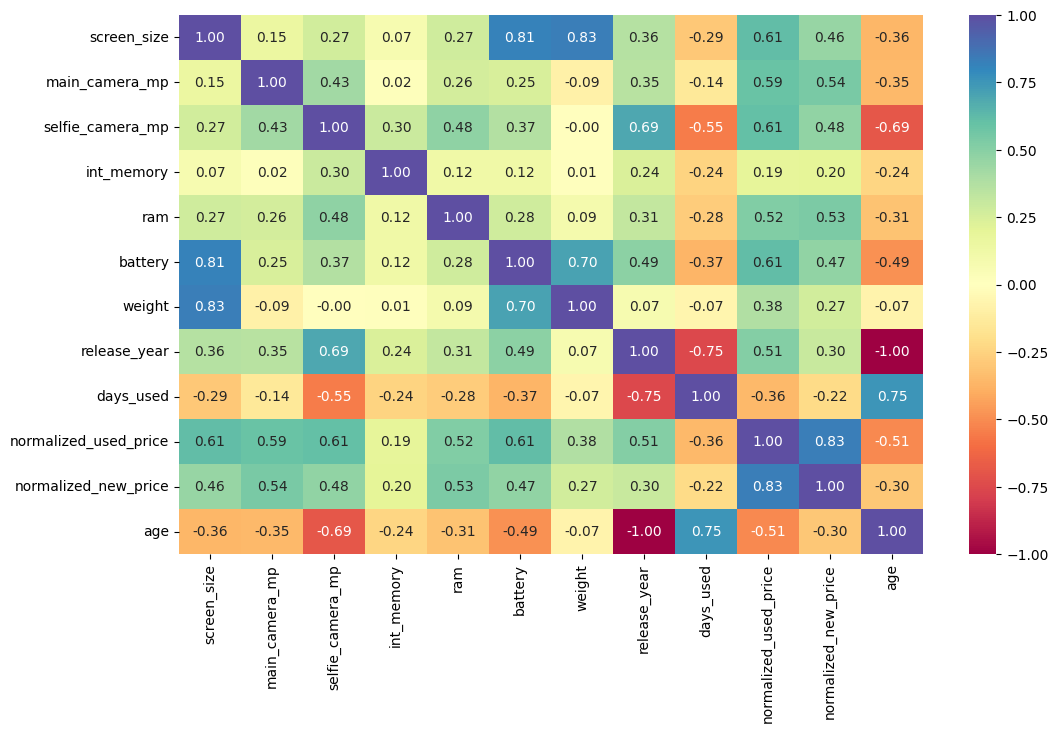

In [ ]:
#Create a correlation matrix to correlate the attributes with price of used devices
# creating a list of numerical columns
num_cols = df1.select_dtypes(include=np.number).columns.tolist()
print(num_cols)

#Plot heatmap
plt.figure(figsize=(12, 7))
sns.heatmap(
    df1[num_cols].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()


- The corellation between main camera mp and normalized used price has a minimal change from 0.55 to 0.59.
- The rest of the corelations are unchanged.

## Model Building - Linear Regression

In [ ]:
olsmodel = sm.OLS(y_train, x_train).fit()
print(olsmodel.summary())

                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.845
Model:                               OLS   Adj. R-squared:                  0.842
Method:                    Least Squares   F-statistic:                     253.6
Date:                   Sat, 11 Jan 2025   Prob (F-statistic):               0.00
Time:                           13:44:17   Log-Likelihood:                 127.77
No. Observations:                   2417   AIC:                            -151.5
Df Residuals:                       2365   BIC:                             149.6
Df Model:                             51                                         
Covariance Type:               nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------


### Interpret the regression results

- R-squared: 84.5% of the variance of the normalized used price is explained by the model
- Adj. R-squared: 0.842 is good.
- Value for constant coefficient is 1.3


## Model Performance Check

In [ ]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute MAPE
def mape_score(targets, predictions):
    return np.mean(np.abs(targets - predictions) / targets) * 100


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mape_score(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],)
    return df_perf

In [ ]:
# checking model performance on train set (seen 70% data)
model_performance_regression(olsmodel, x_train, y_train)


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.229511,0.179849,0.845388,0.841987,4.316331


In [ ]:
# checking model performance on test set (seen 30% data)
model_performance_regression(olsmodel, x_test, y_test)

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.238634,0.184278,0.842114,0.833771,4.491491


- The training R-squared is 0.84. The model is not underfitting.

- The train and test RMSE and MAE are comparable. The model is not overfitting.

- MAE suggests that the model can predict normalized used price  within a mean error of 0.18 on the test data, which is a low value.

- MAPE of 4.49 on the test data means that we are able to predict within 4.5% of the normalized used price.

## Checking Linear Regression Assumptions

- In order to make statistical inferences from a linear regression model, it is important to ensure that the assumptions of linear regression are satisfied.

### Check for multicollinearity

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def checking_vif(predictors):
    """
    Function to calculate VIF
    predictors: independent variables
    """
    vif = pd.DataFrame()  # Changed pd.DatetimeTZDtypeata() to pd.DataFrame()
    vif['Features'] = predictors.columns
    vif['VIF'] = [variance_inflation_factor(predictors.values, i) for i in range(predictors.shape[1])]
    vif['VIF'] = round(vif['VIF'], 2)
    vif = vif.sort_values(by='VIF', ascending=False)
    return vif




In [ ]:
checking_vif(x_train)

,Features,VIF
0,const,313.61
15,brand_name_Apple,13.60
49,os_iOS,12.31
37,brand_name_Others,9.71
1,screen_size,8.33
40,brand_name_Samsung,7.54
7,weight,6.59
6,battery,6.33
24,brand_name_Huawei,5.99
3,selfie_camera_mp,5.78


In [ ]:
def treating_multicollinearity(predictors, target, high_vif_columns):
    """
    Checking the effect of dropping the columns showing high multicollinearity
    on model performance (adj. R-squared and RMSE)

    predictors: independent variables
    target: dependent variable
    high_vif_columns: columns having high VIF
    """
    # empty lists to store adj. R-squared and RMSE values
    adj_r2 = []
    rmse = []

    # build ols models by dropping one of the high VIF columns at a time
    # store the adjusted R-squared and RMSE in the lists defined previously
    for cols in high_vif_columns:
        # defining the new train set
        train = predictors.loc[:, ~predictors.columns.str.startswith(cols)]

        # create the model
        olsmodel = sm.OLS(target, train).fit()

        # adding adj. R-squared and RMSE to the lists
        adj_r2.append(olsmodel.rsquared_adj)
        rmse.append(np.sqrt(olsmodel.mse_resid))

    # creating a dataframe for the results
    temp = pd.DataFrame(
        {
            "col": high_vif_columns,
            "Adj. R-squared after_dropping col": adj_r2,
            "RMSE after dropping col": rmse,
        }
    ).sort_values(by="Adj. R-squared after_dropping col", ascending=False)
    temp.reset_index(drop=True, inplace=True)

    return temp



- High VIF value is seen in the brandname:apple, indicating presence of strong multicollinearity

In [ ]:
def treating_multicollinearity(predictors, target, high_vif_columns):
    """
    Checking the effect of dropping the columns showing high multicollinearity
    on model performance (adj. R-squared and RMSE)

    predictors: independent variables
    target: dependent variable
    high_vif_columns: columns having high VIF
    """
    # empty lists to store adj. R-squared and RMSE values
    adj_r2 = []
    rmse = []

    # build ols models by dropping one of the high VIF columns at a time
    # store the adjusted R-squared and RMSE in the lists defined previously
    for cols in high_vif_columns:
        # defining the new train set
        train = predictors.loc[:, ~predictors.columns.str.startswith(cols)]

        # create the model
        olsmodel = sm.OLS(target, train).fit()

        # adding adj. R-squared and RMSE to the lists
        adj_r2.append(olsmodel.rsquared_adj)
        rmse.append(np.sqrt(olsmodel.mse_resid))

    # creating a dataframe for the results
    temp = pd.DataFrame(
        {
            "col": high_vif_columns,
            "Adj. R-squared after_dropping col": adj_r2,
            "RMSE after dropping col": rmse,
        }
    ).sort_values(by="Adj. R-squared after_dropping col", ascending=False)
    temp.reset_index(drop=True, inplace=True)

    return temp

In [ ]:
col_list = ['brand_name_Apple', 'os_Ios']

res = treating_multicollinearity(x_train, y_train, col_list)
res

,col,Adj. R-squared after_dropping col,RMSE after dropping col
0,brand_name_Apple,0.842119,0.231973
1,os_Ios,0.842054,0.232021


In [ ]:
# Create column to drop
col_to_drop ='brand_name_Apple'

# Drop cloumn in x_train and x_test
x_train2 = x_train.loc[:, ~x_train.columns.str.startswith(col_to_drop)]
x_test2 = x_test.loc[:, ~x_test.columns.str.startswith(col_to_drop)]

# Check VIF now
vif = checking_vif(x_train2)
print("VIF after dropping ", col_to_drop)
vif



VIF after dropping  brand_name_Apple


,Features,VIF
0,const,312.25
36,brand_name_Others,9.12
1,screen_size,8.33
39,brand_name_Samsung,7.03
7,weight,6.59
6,battery,6.33
3,selfie_camera_mp,5.77
23,brand_name_Huawei,5.62
13,age,4.93
26,brand_name_LG,4.58


### Rebuild model

In [ ]:
# rebuild model after changes to predictors
olsmodel1=sm.OLS(y_train,x_train2).fit()
print(olsmodel1.summary())


                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.845
Model:                               OLS   Adj. R-squared:                  0.842
Method:                    Least Squares   F-statistic:                     258.7
Date:                   Sat, 11 Jan 2025   Prob (F-statistic):               0.00
Time:                           13:08:08   Log-Likelihood:                 127.76
No. Observations:                   2417   AIC:                            -153.5
Df Residuals:                       2366   BIC:                             141.8
Df Model:                             50                                         
Covariance Type:               nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------


R-squared: 84.5% of the variance of the normalized used price is explained by the model
Adj. R-squared: 0.842 is unchanged which confirms that the dropped column did not have a great effect on the model.


### Refine model dealing with high p-values

In [ ]:
# initial list of columns
predictors = x_train2.copy()
cols = predictors.columns.tolist()

# setting an initial max p-value
max_p_value = 1

while len(cols) > 0:
    # defining the train set
    x_train_aux = predictors[cols]
 # fitting the model
    model = sm.OLS(y_train, x_train_aux).fit()

    # getting the p-values and the maximum p-value
    p_values = model.pvalues
    max_p_value = max(p_values)

    # name of the variable with maximum p-value
    feature_with_p_max = p_values.idxmax()

    if max_p_value > 0.05:
        cols.remove(feature_with_p_max)
    else:
        break
selected_features = cols
print(selected_features)


['const', 'screen_size', 'main_camera_mp', 'selfie_camera_mp', 'ram', 'battery', 'weight', 'normalized_new_price', 'large_selfie_cam', 'age', 'brand_name_Lenovo', 'brand_name_Nokia', 'brand_name_Realme', 'brand_name_Xiaomi', 'os_Others', '4g_yes']


In [ ]:
x_train3 = x_train2[selected_features]
x_test3 = x_test2[selected_features]

In [ ]:

olsmodel2 = sm.OLS(y_train, x_train3).fit()  # Assigning model to olsmodel2
print(olsmodel2.summary())

                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.843
Model:                               OLS   Adj. R-squared:                  0.842
Method:                    Least Squares   F-statistic:                     859.1
Date:                   Sat, 11 Jan 2025   Prob (F-statistic):               0.00
Time:                           13:08:09   Log-Likelihood:                 108.82
No. Observations:                   2417   AIC:                            -185.6
Df Residuals:                       2401   BIC:                            -93.00
Df Model:                             15                                         
Covariance Type:               nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
co

In [ ]:
# checking model performance on train set (seen 70% data)
olsmod2_test_performance=model_performance_regression(olsmodel2, x_train3, y_train)
olsmod2_test_performance

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.231318,0.181269,0.842945,0.841898,4.349488


In [ ]:
# checking model performance on test set (seen 30% data)
olsmod2_test_performance=model_performance_regression(olsmodel2, x_test3, y_test)
olsmod2_test_performance

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.237065,0.18305,0.844183,0.841739,4.457824


- R-squared is 84.4 % explaining the variance in the model
- Adjusted R-squared is 0.842, thus dropping the columns did not influence the model.
- RMSE and MAE values are comparable for train and test sets, indicating that the model is not overfitting.

### Linearity check

In [ ]:
# create a dataframe with actual, fitted and residual values
df_pred = pd.DataFrame()

df_pred["Actual Values"] = y_train  # actual values
df_pred["Fitted Values"] = olsmodel2.fittedvalues  # predicted values
df_pred["Residuals"] = olsmodel2.resid  # residuals

df_pred.head()

,Actual Values,Fitted Values,Residuals
3026,4.087488,3.859541,0.227947
1525,4.448399,4.626289,-0.177890
1128,4.315353,4.275573,0.039780
3003,4.282068,4.233468,0.048600
2907,4.456438,4.496615,-0.040177


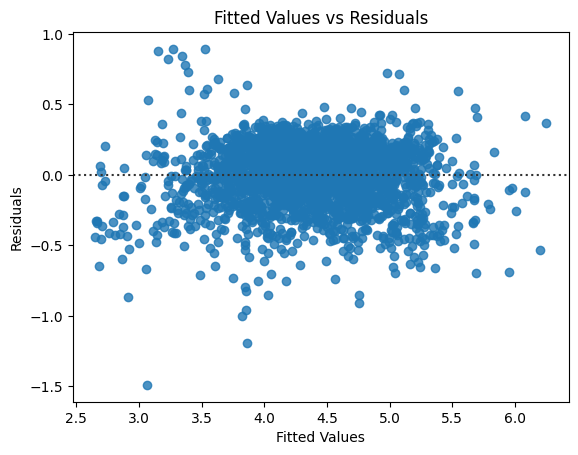

In [ ]:
# plot the fitted values vs residuals
sns.residplot(x="Fitted Values", y="Residuals", data=df_pred)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Fitted Values vs Residuals")
plt.show()

- There is no pattern in the plot.
- The linearity and independance assumptions are met

### Test for normality

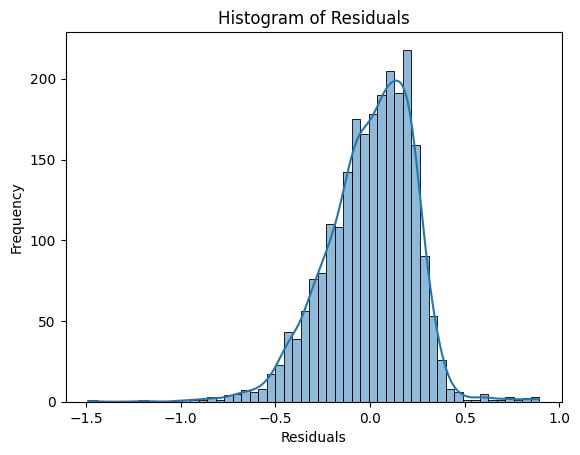

In [ ]:
# Check for normality of residuals via histogram
sns.histplot(df_pred["Residuals"], kde=True)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()

- The histogram has a bormal distribution.

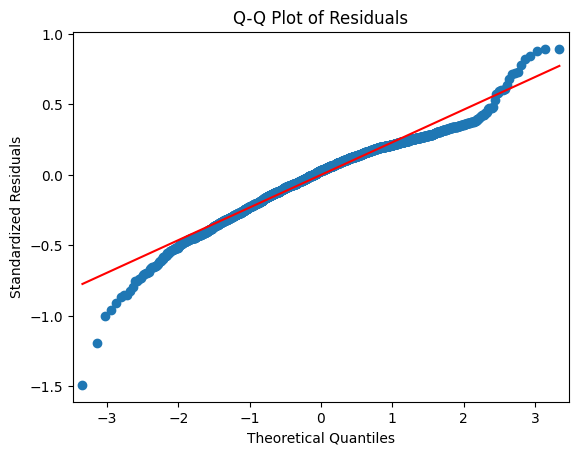

In [ ]:
# Check the Q-q plot
sm.qqplot(df_pred["Residuals"], line="s")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Standardized Residuals")
plt.title("Q-Q Plot of Residuals")
plt.show()

- The residuals more or less follow a straight line except for the tails.


In [ ]:
#check the results of the Shapiro-Wilk test.
from scipy.stats import shapiro
shapiro(df_pred["Residuals"])

ShapiroResult(statistic=0.9694645526540445, pvalue=2.874621837376443e-22)

- Since p-value < 0.05, the residuals are not normal as per the Shapiro-Wilk test.
- Strictly speaking, the residuals are not normal.
-However, as an approximation, we can accept this distribution as close to being normal and the assumption is met.

# Test for homoscedasticity


In [ ]:
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

name = ["F statistic", "p-value"]
test = sms.het_goldfeldquandt(df_pred["Residuals"], x_train3)
lzip(name, test)

[('F statistic', 1.051736175305032), ('p-value', 0.191949685029957)]

- p-value is greater than 0.05, thus the residuals are homoscedastic and the assumption is met.

### Predictions on test data

In [ ]:
# Predictions on the test set
pred = olsmodel2.predict(x_test3)

df_pred_test = pd.DataFrame({"Actual": y_test, "Predicted": pred})
df_pred_test.sample(10, random_state=1)

,Actual,Predicted
1995,4.566741,4.371334
2341,3.696103,3.963052
1913,3.592093,3.694358
688,4.306495,4.116360
650,4.522115,5.130576
2291,4.259294,4.390046
40,4.997685,5.436009
1884,3.875359,4.057605
2538,4.206631,4.050853
45,5.380450,5.312440


- The actual and predicted values are comparable.

## Final Model

In [ ]:
#Make a copy as x train final and y train final
x_train_final = x_train3.copy()
y_train_final = y_train.copy()

#Create the final model
olsmodel_final = sm.OLS(y_train_final, x_train_final).fit()
print(olsmodel_final.summary())





                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.843
Model:                               OLS   Adj. R-squared:                  0.842
Method:                    Least Squares   F-statistic:                     859.1
Date:                   Sat, 11 Jan 2025   Prob (F-statistic):               0.00
Time:                           13:08:10   Log-Likelihood:                 108.82
No. Observations:                   2417   AIC:                            -185.6
Df Residuals:                       2401   BIC:                            -93.00
Df Model:                             15                                         
Covariance Type:               nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
co

In [ ]:
# check model performance on train set (seen 70% data)
print("Training Performance\n")
olsmodel_final_train_perf = model_performance_regression(
    olsmodel_final, x_train_final, y_train
)
olsmodel_final_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.231318,0.181269,0.842945,0.841898,4.349488


In [ ]:
 # check model performance on test set (seen 30% data)
print("Test Performance\n")
olsmodel_final_test_perf = model_performance_regression(
    olsmodel_final, x_test3, y_test
)
olsmodel_final_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.237065,0.18305,0.844183,0.841739,4.457824


- The model is able to explain 84.3% of the variation in the data.
- The train and test RMSE and MAE are low and comparable. The model is not suffering from overfitting.
- The MAPE on the test set suggests we can predict within 4.5% of the normalized used price.
- The model olsmodel_final is good for prediction as well as inference purposes.

## Actionable Insights and Recommendations

- The model is able to explain 84.3% of the variation in the data and within 4.5% on normalized used price on the test data, which is good.This indicates that the model is good for prediction as well as inference purposes.
- As the screen-size increases with one unit, the used price increases with 0.0255 units, all other variables held constant.
- As the main camera mp increases with one unit, the used price increases with 0.0212 units, all other variables held constant.
- As the ram increases with one unit, the used price increases with 0.0205 units, all other variables held constant.
- As the large selfie cam mp increases with one unit, the used price increases with 0.0536 units, all other variables held constant.(This is a selfie camera with megapixels above 8 MP).
- Devices using 4G  increase the unit price with one unit,the used price increases with 0.0500 units, all other variables held constant.
- Thus when reselling a device, choosing larger screen size and  larger main camera megapixel with large selfie camera megapixels devices to resell will increase the revenue.
- It is worthwhile to buy and sell brand names Nokia, Lenovo, Realme, and Xiomi will increase the normalized price.
- As increase in a unit of age, leads to a decrease in unit price of -0.0220, it is of value to encourage consumers to sell their devices while they are at a younger age.





___